# Confound Testing: Experimenter + Age_weeks Effects

Tests whether **Experimenter** (Loukia/Ruth) and **Age_weeks** are associated with any outcome metric, using the correct statistical family per metric.

Run this **before** your main Genotype analysis. Any metric with a significant effect in Model C should have Experimenter and/or Age added as covariates in the main Genotype models.

---

### ⚠️ Critical Warning — Collinearity
Experimenter and Age_weeks are **strongly correlated** in this dataset (r=0.76, p=0.0004).  
- Loukia recorded animals aged **64–78 weeks**  
- Ruth recorded animals aged **62–70 weeks**  

Because of this, three models are run per metric:
- **Model A**: `y ~ Experimenter + (1|mouse_name)`
- **Model B**: `y ~ Age_weeks + (1|mouse_name)`  
- **Model C**: `y ~ Experimenter + Age_weeks + (1|mouse_name)` ← **primary model**

The interaction term is **excluded** — not reliably estimable with n=17 animals and correlated predictors.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
from IPython.display import display, HTML
from pathlib import Path
warnings.filterwarnings('ignore')

# ── rpy2 setup ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import rpy2.robjects.packages as rpackages

# Suppress R output in notebook
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging
rpy2_logger.setLevel(logging.ERROR)

# Load R packages
ro.r("""
suppressPackageStartupMessages({
  library(glmmTMB)
  library(car)
  library(dplyr)
})
""")

print("✅ All packages loaded successfully")

✅ All packages loaded successfully


## 2. Load and Prepare Data

In [29]:
# ── Load data ────────────────────────────────────────────────────────────────
OPEN_FIELD_CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/concatenated_trials.csv')
OPEN_FIELD_DIR = OPEN_FIELD_CSV_PATH.parent

DATA_PATH   = OPEN_FIELD_CSV_PATH
OUTPUT_DIR  = OPEN_FIELD_DIR / "confound_testing_output"   # ← output folder
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df = df.rename(columns={'Cell type': 'Cell_type'})  # remove space for easier handling

# ── Preprocessing ────────────────────────────────────────────────────────────
# Fisher Z transform for correlation-based stability metrics
df['half_split_z'] = np.arctanh(df['half_split_stability'].clip(-0.9999, 0.9999))
df['odd_even_z']   = np.arctanh(df['odd_even_stability'].clip(-0.9999, 0.9999))

# Phase locking binary classification
df['phase_locked'] = (df['phase_locking_pval'] < 0.05).astype(int)

# Scale Age_weeks
df['Age_weeks_scaled'] = (df['Age_weeks'] - df['Age_weeks'].mean()) / df['Age_weeks'].std()

df['log_field_size'] = np.log1p(df['field_size'])

print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   Animals: {df['mouse_name'].nunique()}")
print(f"   Environments: {df['environment'].unique()}")
print(f"   Cell types: {df['Cell_type'].unique()}")
print(f"   Experimenters: {df['Experimenter'].unique()}")
print(f"   Age range: {df['Age_weeks'].min():.1f} - {df['Age_weeks'].max():.1f} weeks")

# ── Cell counts per environment × cell type ──────────────────────────────────
print("\n── Cell counts: environment × Cell_type ──")
ct_counts = df.groupby(['environment', 'Cell_type']).agg(
    n_cells=('mouse_name', 'count'),
    n_mice=('mouse_name', 'nunique')
)
print(ct_counts)
print(f"\nTotal cells: {len(df)}")

# ── Cell counts per genotype × environment × cell type ───────────────────────
print("\n── Cell counts: Genotype × environment × Cell_type ──")
gt_counts = df.groupby(['Genotype', 'environment', 'Cell_type']).agg(
    n_cells=('mouse_name', 'count'),
    n_mice=('mouse_name', 'nunique')
)
print(gt_counts)

print(df.head())

✅ Data loaded: 1838 rows, 41 columns
   Animals: 17
   Environments: ['open_field' 'linear_track']
   Cell types: ['Pyramidal' 'Interneuron']
   Experimenters: ['Loukia' 'Ruth']
   Age range: 61.7 - 78.3 weeks

── Cell counts: environment × Cell_type ──
                          n_cells  n_mice
environment  Cell_type                   
linear_track Interneuron      243      17
             Pyramidal        517      17
open_field   Interneuron      347      17
             Pyramidal        731      17

Total cells: 1838

── Cell counts: Genotype × environment × Cell_type ──
                                   n_cells  n_mice
Genotype environment  Cell_type                   
NLGF     linear_track Interneuron      145       9
                      Pyramidal        222       9
         open_field   Interneuron      205       9
                      Pyramidal        316       9
WT       linear_track Interneuron       98       8
                      Pyramidal        295       8
         ope

In [3]:
# ── Check collinearity ───────────────────────────────────────────────────────
from scipy.stats import pointbiserialr

animal_summary = df.groupby(['mouse_name', 'Experimenter'])['Age_weeks'].first().reset_index()
exp_binary = (animal_summary['Experimenter'] == 'Loukia').astype(int)
r, p = pointbiserialr(exp_binary, animal_summary['Age_weeks'])

print("⚠️  Experimenter-Age collinearity check (animal level):")
print(f"   Correlation: r = {r:.3f}, p = {p:.4f}")
print()
for exp in ['Loukia', 'Ruth']:
    ages = animal_summary[animal_summary['Experimenter'] == exp]['Age_weeks']
    print(f"   {exp}: {len(ages)} animals, age {ages.min():.1f}–{ages.max():.1f} weeks")

print()
if abs(r) > 0.5:
    print("⚠️  HIGH collinearity detected. Interpret Model C results carefully.")
    print("   Effects in Model A and B may reflect the same underlying variable.")
else:
    print("✅ Collinearity is acceptable.")

⚠️  Experimenter-Age collinearity check (animal level):
   Correlation: r = 0.760, p = 0.0004

   Loukia: 10 animals, age 64.4–78.3 weeks
   Ruth: 7 animals, age 61.7–70.4 weeks

⚠️  HIGH collinearity detected. Interpret Model C results carefully.
   Effects in Model A and B may reflect the same underlying variable.


# *What Cells 3a and 3b produce*
| Output | Location|
|---|---|
| `Summary table (skewness, tests, suggested family)	` | distribution_diagnostics_summary.csv |
| `Histograms + QQ plots per metric	` | distribution_histograms_qq.pdf |
| `Residuals vs fitted + QQ + overdispersion per model	` | model_diagnostics_residuals.pdf |
| `Model diagnostics table	` | model_diagnostics_summary.csv|

## Empirical (Cell 3a) vs Model-Based (Cell 3b)

**Empirical diagnostics** look at the raw data *before* fitting any model. They answer: **"What does this variable look like?"**

- Histograms, skewness, kurtosis → is it symmetric, skewed, bounded?
- Shapiro-Wilk → is it plausibly Normal?
- KS tests → does it fit a Gamma/Beta distribution?
- % zeros, integer check, value bounds → count data? proportions? binary?

This tells you which family *should* be appropriate based on the data's marginal distribution. It's fast and doesn't require R. But it has a limitation: GLMMs model the **conditional** distribution (after accounting for fixed and random effects), not the marginal. The raw data might look non-Normal simply because Experimenter/Age shift the mean across groups.

**Model-based diagnostics** fit the actual GLMM with your chosen family, then inspect what's left over. They answer: **"Does the model fit well?"**

- Residuals vs fitted → systematic patterns mean the mean structure or link function is wrong
- QQ of residuals → heavy tails or curvature mean the family's variance function is wrong
- Overdispersion ratio → variance exceeds what the family predicts (e.g. Poisson underfitting count data)
- Zero-inflation check → more zeros than the family can generate
- RE variance → is the random intercept doing anything, or is it collapsed to zero?
- DHARMa → simulation-based "gold standard" that works for any family

## When they disagree

| Scenario | Empirical says | Model says | Trust |
|----------|---------------|------------|-------|
| Skewed raw data, but group means explain the skew | "Use Gamma" | Gaussian residuals look fine | Model-based |
| Raw data looks Normal, but model residuals are funnelled | "Gaussian" | Overdispersion / heteroscedasticity | Model-based |
| Both agree on Gamma | "Gamma" | Clean residuals | Confirmed |

**Bottom line**: Empirical diagnostics are a sensible first pass to choose candidate families. Model-based diagnostics are the definitive check — if residuals look good, the family is appropriate regardless of what the raw histogram looks like. 



## 3a. Distribution Diagnostics

Empirical checks to validate the statistical family for each metric:
1. Summary statistics (skewness, kurtosis, % zeros, bounds)
2. Histograms with KDE overlay
3. QQ plots against Normal distribution
4. Formal distribution tests (Shapiro-Wilk, KS against Gamma/Beta)
5. Automated family suggestion based on data characteristics

In [4]:
# ── Empirical distribution diagnostics ───────────────────────────────────────
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde, shapiro, kstest, gamma as gamma_dist, beta as beta_dist
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Metrics to check: (column, description, expected_type)
# expected_type guides which tests to run # TODO:HOW MANY IS IT TESTING? 
METRICS_TO_CHECK = [
    ('num_spikes',                     'Spike count',                    'count'),
    ('peak_rate',                      'Peak firing rate',               'positive'),
    ('mean_rate',                      'Mean firing rate',               'positive'),
    ('spike_width',                    'Spike width',                    'continuous'),
    ('ahp_decay',                      'AHP decay',                      'continuous'),
    ('overdispersion',                 'Overdispersion index',            'positive'),
    ('theta_mod_v3',                   'Theta modulation v3',             'continuous'),
    ('field_size',                     'Place field size',                'positive'),
    ('spatial_info',                   'Spatial information',             'positive'),
    ('coherence',                      'Spatial coherence',               'continuous'),
    ('spatial_sparsity',               'Spatial sparsity',                'proportion'),
    ('kl_spatial_sparsity',            'KL spatial sparsity',             'positive'),
    ('head_dir_kl_div',                'Head direction KL divergence',    'positive'),
    ('half_split_stability',           'Half-split stability (raw)',      'correlation'),
    ('odd_even_stability',             'Odd-even stability (raw)',        'correlation'),
    ('half_split_z',                   'Half-split stability (Fisher Z)', 'continuous'),
    ('odd_even_z',                     'Odd-even stability (Fisher Z)',   'continuous'),
    ('phase_variance',                 'Phase variance',                  'proportion'),
    ('phase_locking_vector_length',    'Phase locking vector length',     'proportion'),
    ('phase_locked',                   'Phase locked (binary)',            'binary'),
    ('head_dir_mean_resultant_length', 'Head dir resultant length',       'proportion'),
]

ENVIRONMENTS = ['open_field', 'linear_track']
CELL_TYPES = ['Pyramidal', 'Interneuron']

# ── 1. Compute summary statistics ────────────────────────────────────────────
summary_rows = []

for col, desc, expected in METRICS_TO_CHECK:
    if col not in df.columns:
        print(f"  ⚠️  Column '{col}' not found — skipping")
        continue

    for env in ENVIRONMENTS:
        for ct in CELL_TYPES:
            vals = df[(df['environment'] == env) & (df['Cell_type'] == ct)][col].dropna()
            if len(vals) < 5:
                continue

            v = vals.values.astype(float)
            n_zeros = (v == 0).sum()
            n_ones  = (v == 1).sum()

            # Shapiro-Wilk (sample up to 5000 for speed)
            try:
                sw_stat, sw_p = shapiro(v if len(v) <= 5000 else
                                        np.random.default_rng(42).choice(v, 5000, replace=False))
            except Exception:
                sw_stat, sw_p = np.nan, np.nan

            # KS test against Gamma (only for strictly positive data)
            ks_gamma_p = np.nan
            if (v > 0).all() and expected in ('positive', 'count'):
                try:
                    shape_hat, _, scale_hat = gamma_dist.fit(v, floc=0)
                    _, ks_gamma_p = kstest(v, 'gamma', args=(shape_hat, 0, scale_hat))
                except Exception:
                    pass

            # KS test against Beta (only for (0,1) data)
            ks_beta_p = np.nan
            if expected == 'proportion':
                v_inner = v[(v > 0) & (v < 1)]
                if len(v_inner) > 10:
                    try:
                        a_hat, b_hat, _, _ = beta_dist.fit(v_inner, floc=0, fscale=1)
                        _, ks_beta_p = kstest(v_inner, 'beta', args=(a_hat, b_hat, 0, 1))
                    except Exception:
                        pass

            # Variance-to-mean ratio (for count data)
            vmr = (v.var() / v.mean()) if v.mean() > 0 else np.nan

            summary_rows.append({
                'metric': col, 'environment': env, 'cell_type': ct,
                'n': len(v),
                'mean': v.mean(), 'median': np.median(v), 'std': v.std(),
                'min': v.min(), 'max': v.max(),
                'skewness': float(pd.Series(v).skew()),
                'kurtosis': float(pd.Series(v).kurtosis()),
                'pct_zeros': 100 * n_zeros / len(v),
                'pct_ones': 100 * n_ones / len(v),
                'all_positive': bool((v > 0).all()),
                'bounded_0_1': bool(((v >= 0) & (v <= 1)).all()),
                'is_integer': bool(np.allclose(v, np.round(v))),
                'var_mean_ratio': vmr,
                'shapiro_p': sw_p,
                'ks_gamma_p': ks_gamma_p,
                'ks_beta_p': ks_beta_p,
                'expected_type': expected,
            })

df_diag = pd.DataFrame(summary_rows)

# ── 2. Suggest family based on data characteristics ──────────────────────────
def suggest_family(row):
    if row['expected_type'] == 'binary':
        return 'binomial'
    if row['expected_type'] == 'proportion' and row['bounded_0_1']:
        return 'beta'
    if row['expected_type'] == 'count' and row['is_integer'] and row['min'] >= 0:
        return 'nbinom2' if row['var_mean_ratio'] > 1.5 else 'poisson'
    if row['all_positive'] and row['skewness'] > 1.0:
        return 'Gamma'
    if row['all_positive'] and row['skewness'] > 0.5:
        return 'Gamma (borderline)'
    if abs(row['skewness']) < 1.5:
        return 'gaussian'
    return '⚠️ check manually'

df_diag['suggested_family'] = df_diag.apply(suggest_family, axis=1)

# Display summary
display(HTML("<h3>Distribution Diagnostics — Summary Table</h3>"))
show_cols = ['metric', 'environment', 'cell_type', 'n', 'mean', 'std',
             'skewness', 'kurtosis', 'pct_zeros', 'all_positive', 'bounded_0_1',
             'var_mean_ratio', 'shapiro_p', 'ks_gamma_p', 'ks_beta_p', 'suggested_family']
styled = (df_diag[show_cols].style
          .format({'mean':'{:.3f}', 'std':'{:.3f}', 'skewness':'{:.2f}',
                   'kurtosis':'{:.2f}', 'pct_zeros':'{:.1f}', 'var_mean_ratio':'{:.2f}',
                   'shapiro_p':'{:.4f}', 'ks_gamma_p':'{:.4f}', 'ks_beta_p':'{:.4f}'})
          .applymap(lambda x: 'background-color: #fbc02d' if isinstance(x, str) and '⚠️' in x else '',
                    subset=['suggested_family']))
display(styled)

diag_csv = os.path.join(OUTPUT_DIR, "3a_Distribution_diagnostics_summary.csv")
df_diag.to_csv(diag_csv, index=False)
print(f"✅ Summary saved to: {diag_csv}")

# ── 3. Multi-page PDF: Histograms + QQ plots ────────────────────────────────
pdf_hist = os.path.join(OUTPUT_DIR, "3a_distribution_histograms_qq.pdf")

with PdfPages(pdf_hist) as pdf:
    for col, desc, expected in METRICS_TO_CHECK:
        if col not in df.columns:
            continue

        combos = [(env, ct) for env in ENVIRONMENTS for ct in CELL_TYPES]
        n_combos = len(combos)
        fig, axes = plt.subplots(2, n_combos, figsize=(5 * n_combos, 9))
        if n_combos == 1:
            axes = axes.reshape(2, 1)
        fig.suptitle(f'{col} — {desc}\nExpected type: {expected}',
                     fontsize=13, fontweight='bold', y=1.02)

        for idx, (env, ct) in enumerate(combos):
            vals = df[(df['environment'] == env) & (df['Cell_type'] == ct)][col].dropna().values.astype(float)

            # ── Histogram ──
            ax = axes[0, idx]
            if len(vals) < 5:
                ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                        transform=ax.transAxes)
                axes[1, idx].text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                                  transform=axes[1, idx].transAxes)
                ax.set_title(f'{env} | {ct}', fontsize=9)
                continue

            ax.hist(vals, bins=min(50, max(10, len(vals)//10)), density=True,
                    alpha=0.7, edgecolor='black', linewidth=0.3, color='steelblue')
            try:
                kde = gaussian_kde(vals)
                x_range = np.linspace(vals.min(), vals.max(), 300)
                ax.plot(x_range, kde(x_range), 'r-', lw=1.5, label='KDE')
            except Exception:
                pass

            skew = float(pd.Series(vals).skew())
            ax.set_title(f'{env} | {ct}\nn={len(vals)}, skew={skew:.2f}', fontsize=9)
            ax.set_xlabel(col, fontsize=8)
            ax.set_ylabel('Density', fontsize=8)

            # ── QQ plot ──
            ax2 = axes[1, idx]
            sp_stats.probplot(vals, dist='norm', plot=ax2)
            ax2.set_title(f'QQ vs Normal | {env} | {ct}', fontsize=9)
            ax2.get_lines()[0].set_markersize(2)  # smaller points

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"✅ Histogram + QQ plots saved to: {pdf_hist}")

,metric,environment,cell_type,n,mean,std,skewness,kurtosis,pct_zeros,all_positive,bounded_0_1,var_mean_ratio,shapiro_p,ks_gamma_p,ks_beta_p,suggested_family
0,num_spikes,open_field,Pyramidal,731,1766.565,2248.249,3.41,15.74,0.0,True,False,2861.27,0.0000,0.0002,nan,nbinom2
1,num_spikes,open_field,Interneuron,347,6141.513,9564.862,2.44,6.39,0.0,True,False,14896.42,0.0000,0.0000,nan,nbinom2
2,num_spikes,linear_track,Pyramidal,517,1401.905,1472.511,2.81,10.68,0.0,True,False,1546.67,0.0000,0.0059,nan,nbinom2
3,num_spikes,linear_track,Interneuron,243,4745.284,7052.277,4.21,30.40,0.0,True,False,10480.85,0.0000,0.0001,nan,nbinom2
4,peak_rate,open_field,Pyramidal,731,2.302,2.371,2.33,7.58,0.0,True,False,2.44,0.0000,0.0084,nan,Gamma
5,peak_rate,open_field,Interneuron,347,4.510,6.547,2.45,6.67,0.0,True,False,9.51,0.0000,0.0000,nan,Gamma
6,peak_rate,linear_track,Pyramidal,517,3.227,2.852,1.76,3.33,0.0,True,False,2.52,0.0000,0.1247,nan,Gamma
7,peak_rate,linear_track,Interneuron,243,6.077,7.968,3.75,24.04,0.0,True,False,10.45,0.0000,0.0005,nan,Gamma
8,mean_rate,open_field,Pyramidal,731,0.898,1.199,4.17,25.99,0.0,True,False,1.60,0.0000,0.0001,nan,Gamma
9,mean_rate,open_field,Interneuron,347,3.186,5.030,2.55,7.08,0.0,True,False,7.94,0.0000,0.0000,nan,Gamma


✅ Summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3a_Distribution_diagnostics_summary.csv
✅ Histogram + QQ plots saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3a_distribution_histograms_qq.pdf


## 3b. Model-Based Diagnostics

Fits each proposed GLMM and checks:
- Pearson residuals vs fitted values
- QQ plot of residuals
- Overdispersion ratio (Pearson χ² / residual df; flag if >1.5)
- Zero-inflation (observed vs expected % zeros)
- Random effects variance (mouse-level)
- DHARMa simulated residuals (if installed)

✅ DHARMa loaded — will use simulated residuals
[1/76] num_spikes (nbinom2) | open_field | Pyramidal... overdisp=1.46 ✅  RE=0.0860 ✅  zeros=0% ✅
[2/76] num_spikes (nbinom2) | open_field | Interneuron... overdisp=1.55 ⚠️  RE=0.2543 ✅  zeros=0% ✅
[3/76] num_spikes (nbinom2) | linear_track | Pyramidal... overdisp=1.38 ✅  RE=0.0693 ✅  zeros=0% ✅
[4/76] num_spikes (nbinom2) | linear_track | Interneuron... overdisp=1.82 ⚠️  RE=0.0002 ✅  zeros=0% ✅
[5/76] peak_rate (Gamma) | open_field | Pyramidal... overdisp=0.83 ✅  RE=0.1083 ✅  zeros=0% ✅
[6/76] peak_rate (Gamma) | open_field | Interneuron... overdisp=1.90 ⚠️  RE=0.2315 ✅  zeros=0% ✅
[7/76] peak_rate (Gamma) | linear_track | Pyramidal... overdisp=0.60 ✅  RE=0.0900 ✅  zeros=0% ✅
[8/76] peak_rate (Gamma) | linear_track | Interneuron... overdisp=1.65 ⚠️  RE=0.0023 ✅  zeros=0% ✅
[9/76] mean_rate (Gamma) | open_field | Pyramidal... overdisp=1.28 ✅  RE=0.1031 ✅  zeros=0% ✅
[10/76] mean_rate (Gamma) | open_field | Interneuron... overdisp=2.44 ⚠️  R

,metric,environment,cell_type,family,n,n_mice,converged,overdispersion,overdisp_flag,RE_variance,RE_flag,pct_zeros_obs,pct_zeros_expected,zi_flag,AIC,dharma_uniformity_p,dharma_dispersion_p,dharma_outliers_p
0,num_spikes,open_field,Pyramidal,nbinom2,731,17,True,1.46,✅,0.08598,✅,0.0,0.0,✅,12343.3,0.161,0.044,0.225
1,num_spikes,open_field,Interneuron,nbinom2,347,17,True,1.55,⚠️,0.25434,✅,0.0,0.4,✅,6646.1,0.001,0.892,0.360
2,num_spikes,linear_track,Pyramidal,nbinom2,517,17,True,1.38,✅,0.06928,✅,0.0,0.0,✅,8457.2,0.130,0.128,0.154
3,num_spikes,linear_track,Interneuron,nbinom2,243,17,True,1.82,⚠️,0.00016,✅,0.0,0.1,✅,4571.0,0.003,0.060,0.360
4,peak_rate,open_field,Pyramidal,Gamma,731,17,True,0.83,✅,0.10828,✅,0.0,0.0,✅,2554.6,0.063,0.856,0.770
5,peak_rate,open_field,Interneuron,Gamma,347,17,True,1.90,⚠️,0.23150,✅,0.0,0.0,✅,1682.4,0.007,0.980,1.000
6,peak_rate,linear_track,Pyramidal,Gamma,517,17,True,0.60,✅,0.09004,✅,0.0,0.0,✅,2113.1,0.451,0.532,0.281
7,peak_rate,linear_track,Interneuron,Gamma,243,17,True,1.65,⚠️,0.00235,✅,0.0,0.0,✅,1344.6,0.002,0.044,0.017
8,mean_rate,open_field,Pyramidal,Gamma,731,17,True,1.28,✅,0.10311,✅,0.0,0.0,✅,1250.5,0.024,0.052,0.075
9,mean_rate,open_field,Interneuron,Gamma,347,17,True,2.44,⚠️,0.31220,✅,0.0,0.0,✅,1398.2,0.014,0.844,0.403


,metric,environment,cell_type,family,n,n_mice,converged,overdispersion,overdisp_flag,RE_variance,RE_flag,pct_zeros_obs,pct_zeros_expected,zi_flag,AIC,dharma_uniformity_p,dharma_dispersion_p,dharma_outliers_p
1,num_spikes,open_field,Interneuron,nbinom2,347,17,True,1.547151e+00,⚠️,2.543378e-01,✅,0.0,0.350144,✅,6646.066092,1.213222e-03,0.892,3.600000e-01
3,num_spikes,linear_track,Interneuron,nbinom2,243,17,True,1.824337e+00,⚠️,1.642802e-04,✅,0.0,0.074074,✅,4570.986442,2.738339e-03,0.060,3.600000e-01
5,peak_rate,open_field,Interneuron,Gamma,347,17,True,1.900875e+00,⚠️,2.315026e-01,✅,0.0,0.000000,✅,1682.373041,6.897499e-03,0.980,1.000000e+00
7,peak_rate,linear_track,Interneuron,Gamma,243,17,True,1.650386e+00,⚠️,2.349911e-03,✅,0.0,0.000000,✅,1344.597965,1.881804e-03,0.044,1.697334e-02
9,mean_rate,open_field,Interneuron,Gamma,347,17,True,2.435912e+00,⚠️,3.122042e-01,✅,0.0,0.000000,✅,1398.167464,1.381529e-02,0.844,4.033243e-01
11,mean_rate,linear_track,Interneuron,Gamma,243,17,True,2.211618e+00,⚠️,9.873316e-04,✅,0.0,0.000000,✅,1115.972874,2.104131e-04,0.072,1.697334e-02
12,spike_width,open_field,Pyramidal,gaussian,731,17,False,4.569390e+03,⚠️,2.698353e+02,✅,0.0,0.000000,✅,NaN,1.954964e-03,0.380,2.926520e-02
13,spike_width,open_field,Interneuron,gaussian,347,17,True,5.044850e+03,⚠️,4.133855e-34,⚠️ boundary,0.0,0.000000,✅,3950.295064,8.975417e-04,0.984,6.528978e-01
14,spike_width,linear_track,Pyramidal,gaussian,517,17,False,3.443846e+03,⚠️,7.778194e+02,✅,0.0,0.000000,✅,NaN,2.416330e-01,0.852,2.806714e-01
15,spike_width,linear_track,Interneuron,gaussian,243,17,True,4.541593e+03,⚠️,5.613412e-102,⚠️ boundary,0.0,0.000000,✅,2742.896544,1.018823e-03,0.924,1.000000e+00



✅ Model diagnostics saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3b.model_diagnostics_summary.csv
✅ Residual plots saved to:    /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3b.model_diagnostics_residuals.pdf


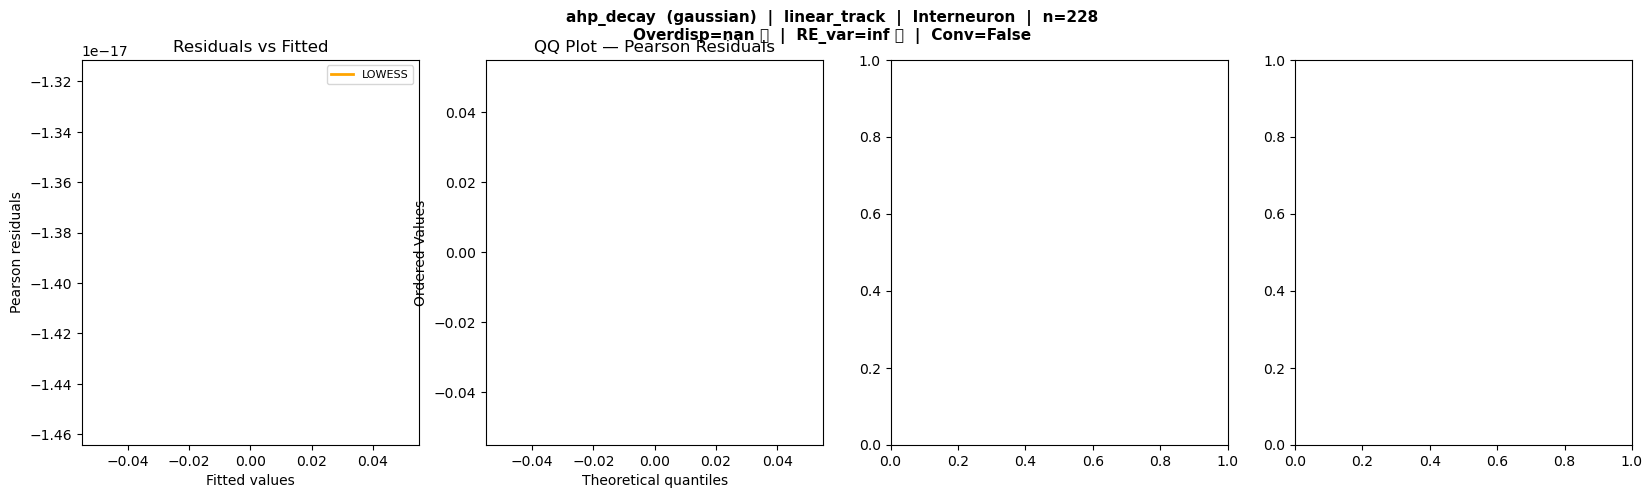

In [25]:
# ── Model-based diagnostics ──────────────────────────────────────────────────
from scipy import stats as sp_stats

# Check for DHARMa
try:
    ro.r('suppressPackageStartupMessages(library(DHARMa))')
    HAS_DHARMA = True
    print("✅ DHARMa loaded — will use simulated residuals")
except Exception:
    HAS_DHARMA = False
    print("⚠️  DHARMa not installed — using Pearson residuals only")
    print("   Install with: install.packages('DHARMa') in R")

# Proposed families (same as METRIC_SPECS, without labels)
# col, family, link, env_restrict
SPECS_TO_CHECK = [
    ('num_spikes',                    'nbinom2',   'log',      None),
    ('peak_rate',                     'Gamma',     'log',      None),
    ('mean_rate',                     'Gamma',     'log',      None),
    ('spike_width',                   'gaussian',  'identity', None),
    ('ahp_decay',                     'gaussian',  'identity', None),
    ('overdispersion',                'Gamma',     'log',      None),
    ('theta_mod_v3',                  'gaussian',  'identity', None),
    ('field_size',                    'gaussian',  'identity', 'open_field'),
    ('field_size',                    'Gamma',     'log',      'linear_track'),
    ('spatial_info',                  'Gamma',     'log',      None),
    ('coherence',                     'gaussian',  'identity', None),
    ('spatial_sparsity',              'beta',      'logit',    None),
    ('kl_spatial_sparsity',           'Gamma',     'log',      'open_field'),
    ('kl_spatial_sparsity',           'gaussian',  'identity', 'linear_track'),
    ('head_dir_kl_div',               'Gamma',     'log',      None),
    ('half_split_z',                  'gaussian',  'identity', None),
    ('odd_even_z',                    'gaussian',  'identity', None),
    ('phase_variance',                'beta',      'logit',    None),
    ('phase_locking_vector_length',   'beta',      'logit',    None),
    ('phase_locked',                  'binomial',  'logit',    None),
    ('head_dir_mean_resultant_length','beta',      'logit',    None),
]

FAMILY_R_MAP = {
    'gaussian': lambda link: f'gaussian(link="{link}")',
    'Gamma':    lambda link: f'Gamma(link="{link}")',
    'nbinom2':  lambda link: 'nbinom2(link="log")',
    'beta':     lambda link: 'beta_family(link="logit")',
    'binomial': lambda link: f'binomial(link="{link}")',
}

model_diag_rows = []
total = sum(1 for (c, f, l, er) in SPECS_TO_CHECK
            for env in ENVIRONMENTS
            for ct in CELL_TYPES
            if er is None or er == env)
done = 0

jpeg_dir = os.path.join(OUTPUT_DIR, "3b_model_diagnostics_jpeg")
os.makedirs(jpeg_dir, exist_ok=True)

pdf_model = os.path.join(OUTPUT_DIR, "3b.model_diagnostics_residuals.pdf")

with PdfPages(pdf_model) as pdf:
    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.text(0.05, 0.9,
             "Model-Based Diagnostics\n\n"
             "For each metric × environment × cell type:\n"
             "  • Pearson residuals vs fitted values\n"
             "  • QQ plot of Pearson residuals\n"
             "  • Residual histogram with overdispersion ratio\n"
             "  • Random effects variance\n"
             + ("  • DHARMa simulated residual diagnostics\n" if HAS_DHARMA else ""),
             fontsize=14, va='top')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    for (col, family, link, env_restrict) in SPECS_TO_CHECK:
        for env in ENVIRONMENTS:
            if env_restrict is not None and env_restrict != env:
                continue
            for ct in CELL_TYPES:
                done += 1
                sub = df[(df['environment'] == env) & (df['Cell_type'] == ct)].copy()
                model_data = sub[['mouse_name', 'Experimenter', 'Age_weeks_scaled', col]].copy()
                model_data = model_data.rename(columns={col: 'y'}).dropna()

                if family == 'beta':
                    model_data = model_data[(model_data['y'] > 0) & (model_data['y'] < 1)]

                if len(model_data) < 10 or model_data['mouse_name'].nunique() < 2:
                    continue

                print(f"[{done}/{total}] {col} ({family}) | {env} | {ct}... ",
                      end='', flush=True)

                # Transfer to R
                with localconverter(ro.default_converter + pandas2ri.converter):
                    r_df = ro.conversion.py2rpy(model_data)
                ro.globalenv['dat'] = r_df

                family_r = FAMILY_R_MAP[family](link)

                try:
                    # Fit model and extract diagnostics
                    ro.r(f"""
                    dat$mouse_name   <- factor(dat$mouse_name)
                    dat$Experimenter <- factor(dat$Experimenter)
                    fit <- glmmTMB(y ~ Experimenter + Age_weeks_scaled + (1|mouse_name),
                                   data=dat, family={family_r},
                                   control=glmmTMBControl(optimizer=optim,
                                                          optArgs=list(method="BFGS")))
                    """)

                    diag = ro.r("""
                    s  <- summary(fit)
                    vc <- VarCorr(fit)
                    re_var <- tryCatch(as.numeric(vc$cond$mouse_name[1,1]),
                                       error=function(e) NA_real_)

                    res_pearson <- residuals(fit, type="pearson")
                    fv          <- fitted(fit)

                    n <- nrow(dat)
                    p <- length(fixef(fit)$cond)
                    overdisp <- sum(res_pearson^2) / (n - p)

                    # Zero counts
                    n_zeros_obs <- sum(dat$y == 0)
                    pct_zeros   <- 100 * n_zeros_obs / n

                    # Expected zeros under the model (simulation-based)
                    exp_zeros <- tryCatch({{
                        sims <- simulate(fit, nsim=200)
                        mean(sapply(sims, function(x) sum(x == 0))) / n * 100
                    }}, error=function(e) NA_real_)

                    # Convergence
                    conv <- tryCatch(fit$sdr$pdHess, error=function(e) FALSE)

                    list(
                        re_var       = re_var,
                        overdisp     = overdisp,
                        n_zeros_obs  = n_zeros_obs,
                        pct_zeros    = pct_zeros,
                        exp_pct_zeros= exp_zeros,
                        aic          = AIC(fit),
                        bic          = BIC(fit),
                        converged    = conv,
                        residuals    = as.numeric(res_pearson),
                        fitted       = as.numeric(fv)
                    )
                    """)

                    # Extract values
                    def _r2f(name):
                        try: return float(list(diag.rx2(name))[0])
                        except: return np.nan
                    def _r2b(name):
                        try: return bool(list(diag.rx2(name))[0])
                        except: return False

                    re_var    = _r2f('re_var')
                    overdisp  = _r2f('overdisp')
                    pct_z_obs = _r2f('pct_zeros')
                    pct_z_exp = _r2f('exp_pct_zeros')
                    aic       = _r2f('aic')
                    bic       = _r2f('bic')
                    converged = _r2b('converged')
                    residuals = np.array(diag.rx2('residuals'))
                    fitted_v  = np.array(diag.rx2('fitted'))

                    # Flags
                    od_flag = '⚠️' if overdisp > 1.5 else ('⚠️ under' if overdisp < 0.5 else '✅')
                    zi_flag = '✅'
                    if not np.isnan(pct_z_exp) and pct_z_obs > 0:
                        zi_ratio = pct_z_obs / max(pct_z_exp, 0.01)
                        zi_flag = '⚠️' if zi_ratio > 1.5 else '✅'
                    else:
                        zi_ratio = np.nan

                    re_flag = '⚠️ boundary' if re_var < 1e-8 else '✅'

                    row = {
                        'metric': col, 'environment': env, 'cell_type': ct,
                        'family': family, 'n': len(model_data),
                        'n_mice': model_data['mouse_name'].nunique(),
                        'AIC': aic, 'BIC': bic, 'converged': converged,
                        'RE_variance': re_var, 'RE_flag': re_flag,
                        'overdispersion': overdisp, 'overdisp_flag': od_flag,
                        'pct_zeros_obs': pct_z_obs, 'pct_zeros_expected': pct_z_exp,
                        'zero_inflation_ratio': zi_ratio, 'zi_flag': zi_flag,
                    }
                    model_diag_rows.append(row)

                    # ── Plot: 3-panel diagnostic ─────────────────────────
                    n_panels = 4 if HAS_DHARMA else 3
                    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
                    fig.suptitle(
                        f'{col}  ({family})  |  {env}  |  {ct}  |  n={len(model_data)}\n'
                        f'Overdisp={overdisp:.2f} {od_flag}  |  RE_var={re_var:.4f} {re_flag}  |  '
                        f'Conv={converged}',
                        fontsize=11, fontweight='bold')

                    # Panel 1: Residuals vs Fitted
                    axes[0].scatter(fitted_v, residuals, alpha=0.25, s=8, edgecolors='none')
                    axes[0].axhline(0, color='red', linestyle='--', lw=1)
                    # Lowess smoothing for trend
                    try:
                        from statsmodels.nonparametric.smoothers_lowess import lowess
                        smooth = lowess(residuals, fitted_v, frac=0.4)
                        axes[0].plot(smooth[:, 0], smooth[:, 1], 'orange', lw=2, label='LOWESS')
                        axes[0].legend(fontsize=8)
                    except ImportError:
                        pass
                    axes[0].set_xlabel('Fitted values')
                    axes[0].set_ylabel('Pearson residuals')
                    axes[0].set_title('Residuals vs Fitted')

                    # Panel 2: QQ plot of residuals
                    sp_stats.probplot(residuals, dist='norm', plot=axes[1])
                    axes[1].set_title('QQ Plot — Pearson Residuals')
                    axes[1].get_lines()[0].set_markersize(2)

                    # Panel 3: Residual histogram + stats
                    axes[2].hist(residuals, bins=40, density=True, alpha=0.7,
                                 edgecolor='black', linewidth=0.3, color='steelblue')
                    # Overlay normal curve
                    x_r = np.linspace(residuals.min(), residuals.max(), 200)
                    axes[2].plot(x_r, sp_stats.norm.pdf(x_r, residuals.mean(), residuals.std()),
                                'r-', lw=1.5, label='Normal fit')
                    axes[2].legend(fontsize=8)
                    axes[2].set_xlabel('Pearson residuals')
                    axes[2].set_title('Residual Distribution')

                    info_txt = (f"Overdispersion: {overdisp:.3f}\n"
                                f"RE variance:    {re_var:.5f}\n"
                                f"AIC: {aic:.1f}  BIC: {bic:.1f}\n"
                                f"Zeros obs: {pct_z_obs:.1f}%\n"
                                f"Zeros exp: {pct_z_exp:.1f}%"
                                if not np.isnan(pct_z_exp) else
                                f"Overdispersion: {overdisp:.3f}\n"
                                f"RE variance:    {re_var:.5f}\n"
                                f"AIC: {aic:.1f}  BIC: {bic:.1f}\n"
                                f"Zeros obs: {pct_z_obs:.1f}%")
                    axes[2].text(0.97, 0.97, info_txt, transform=axes[2].transAxes,
                                ha='right', va='top', fontsize=8,
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

                    # Panel 4: DHARMa (if available)
                    if HAS_DHARMA:
                        try:
                            ro.r("""
                            sim_res <- simulateResiduals(fittedModel=fit, n=500, plot=FALSE)
                            dharma_res   <- sim_res$scaledResiduals
                            dharma_pred  <- sim_res$fittedPredictedResponse
                            dharma_tests <- list(
                                uniformity = testUniformity(sim_res, plot=FALSE)$p.value,
                                dispersion = testDispersion(sim_res, plot=FALSE)$p.value,
                                outliers   = testOutliers(sim_res, plot=FALSE)$p.value
                            )
                            """)
                            d_res  = np.array(ro.r('as.numeric(dharma_res)'))
                            d_pred = np.array(ro.r('as.numeric(dharma_pred)'))
                            d_unif = float(ro.r('dharma_tests$uniformity')[0])
                            d_disp = float(ro.r('dharma_tests$dispersion')[0])
                            d_outl = float(ro.r('dharma_tests$outliers')[0])

                            axes[3].scatter(d_pred, d_res, alpha=0.25, s=8, edgecolors='none')
                            axes[3].axhline(0.25, color='grey', linestyle=':', lw=0.8)
                            axes[3].axhline(0.50, color='red',  linestyle='--', lw=1)
                            axes[3].axhline(0.75, color='grey', linestyle=':', lw=0.8)
                            axes[3].set_xlabel('Predicted')
                            axes[3].set_ylabel('Simulated residuals (scaled)')
                            axes[3].set_title('DHARMa Residuals')
                            axes[3].set_ylim(-0.05, 1.05)

                            dharma_txt = (f"Uniformity: p={d_unif:.3f}\n"
                                          f"Dispersion: p={d_disp:.3f}\n"
                                          f"Outliers:   p={d_outl:.3f}")
                            axes[3].text(0.97, 0.97, dharma_txt, transform=axes[3].transAxes,
                                         ha='right', va='top', fontsize=8,
                                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

                            row['dharma_uniformity_p'] = d_unif
                            row['dharma_dispersion_p'] = d_disp
                            row['dharma_outliers_p']   = d_outl
                        except Exception as e:
                            axes[3].text(0.5, 0.5, f'DHARMa failed:\n{str(e)[:60]}',
                                         ha='center', va='center', transform=axes[3].transAxes,
                                         fontsize=8)

                    plt.tight_layout()
                    pdf.savefig(fig, bbox_inches='tight')
                    # Also save as JPEG
                    jpeg_path = os.path.join(jpeg_dir, f"{col}_{family}_{env}_{ct}.jpg")
                    fig.savefig(jpeg_path, format='jpeg', dpi=150, bbox_inches='tight')
                    plt.close(fig)

                    print(f"overdisp={overdisp:.2f} {od_flag}  RE={re_var:.4f} {re_flag}  "
                          f"zeros={pct_z_obs:.0f}% {zi_flag}")

                except Exception as e:
                    print(f"ERROR: {str(e)[:80]}")
                    model_diag_rows.append({
                        'metric': col, 'environment': env, 'cell_type': ct,
                        'family': family, 'n': len(model_data),
                        'n_mice': model_data['mouse_name'].nunique(),
                        'converged': False, 'error': str(e)[:120],
                        'AIC': np.nan, 'BIC': np.nan,
                        'RE_variance': np.nan, 'RE_flag': '❌',
                        'overdispersion': np.nan, 'overdisp_flag': '❌',
                        'pct_zeros_obs': np.nan, 'pct_zeros_expected': np.nan,
                        'zero_inflation_ratio': np.nan, 'zi_flag': '❌',
                    })

# ── Results summary ──────────────────────────────────────────────────────────
df_model_diag = pd.DataFrame(model_diag_rows)

display(HTML("<h3>Model Diagnostics Summary</h3>"))
show = ['metric', 'environment', 'cell_type', 'family', 'n', 'n_mice',
        'converged', 'overdispersion', 'overdisp_flag',
        'RE_variance', 'RE_flag',
        'pct_zeros_obs', 'pct_zeros_expected', 'zi_flag', 'AIC']
if HAS_DHARMA and 'dharma_dispersion_p' in df_model_diag.columns:
    show += ['dharma_uniformity_p', 'dharma_dispersion_p', 'dharma_outliers_p']
available = [c for c in show if c in df_model_diag.columns]
display(df_model_diag[available].style.format({
    'overdispersion': '{:.2f}', 'RE_variance': '{:.5f}',
    'pct_zeros_obs': '{:.1f}', 'pct_zeros_expected': '{:.1f}', 'AIC': '{:.1f}',
    **({f'dharma_{t}_p': '{:.3f}' for t in ['uniformity', 'dispersion', 'outliers']}
       if HAS_DHARMA and 'dharma_dispersion_p' in df_model_diag.columns else {})
}))

# Flag problematic models
problems = df_model_diag[
    (df_model_diag.get('overdisp_flag', '') == '⚠️') |
    (df_model_diag.get('RE_flag', '') == '⚠️ boundary') |
    (df_model_diag.get('zi_flag', '') == '⚠️') |
    (df_model_diag.get('converged', True) == False)
]
if len(problems) > 0:
    display(HTML("<h3>⚠️ Models with potential issues</h3>"))
    display(problems[available])
else:
    print("\n✅ All models passed basic diagnostics.")

# Save
diag_path = os.path.join(OUTPUT_DIR, "3b.model_diagnostics_summary.csv")
df_model_diag.to_csv(diag_path, index=False)
print(f"\n✅ Model diagnostics saved to: {diag_path}")
print(f"✅ Residual plots saved to:    {pdf_model}")

## 3c. 2nd run ofModel-Based Diagnostics

Fits each proposed GLMM after the results of 3b and checks:
- Pearson residuals vs fitted values
- QQ plot of residuals
- Overdispersion ratio (Pearson χ² / residual df; flag if >1.5)
- Zero-inflation (observed vs expected % zeros)
- Random effects variance (mouse-level)
- DHARMa simulated residuals (if installed)

In [24]:
# ── Model-based diagnostics 2nd check after 3b ──────────────────────────────────────────────────
from matplotlib.pylab import log
from scipy import stats as sp_stats

# Check for DHARMa
try:
    ro.r('suppressPackageStartupMessages(library(DHARMa))')
    HAS_DHARMA = True
    print("✅ DHARMa loaded — will use simulated residuals")
except Exception:
    HAS_DHARMA = False
    print("⚠️  DHARMa not installed — using Pearson residuals only")
    print("   Install with: install.packages('DHARMa') in R")

# Proposed families (same as METRIC_SPECS, without labels)
# col, family, link, env_restrict
SPECS_TO_CHECK = [
    ('overdispersion',                'gaussian',  'identity', None),
    ('overdispersion',                'Gamma',     'log',      None),
    ('log_field_size',                'gaussian',  'identity', None),
    ('field_size',                    'gaussian',  'identity', 'open_field'),
    ('field_size',                    'Gamma',     'log',      'open_field'),
    ('field_size',                    'Gamma',     'log',      'linear_track'),
    ('field_size',                    'gaussian',  'identity', 'linear_track'),
    ('spatial_sparsity',              'gaussian',  'identity',    None),
    ('spatial_sparsity',              'beta',  'logit',    None),
]

FAMILY_R_MAP = {
    'gaussian': lambda link: f'gaussian(link="{link}")',
    'Gamma':    lambda link: f'Gamma(link="{link}")',
    'nbinom2':  lambda link: 'nbinom2(link="log")',
    'beta':     lambda link: 'beta_family(link="logit")',
    'binomial': lambda link: f'binomial(link="{link}")',
}

model_diag_rows = []
total = sum(1 for (c, f, l, er) in SPECS_TO_CHECK
            for env in ENVIRONMENTS
            for ct in CELL_TYPES
            if er is None or er == env)
done = 0

jpeg_dir = os.path.join(OUTPUT_DIR, "3c_model_diagnostics_jpeg")
os.makedirs(jpeg_dir, exist_ok=True)

pdf_model = os.path.join(OUTPUT_DIR, "3c.model_diagnostics_residuals_retest.pdf")

with PdfPages(pdf_model) as pdf:
    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.text(0.05, 0.9,
             "Model-Based Diagnostics\n\n"
             "For each metric × environment × cell type:\n"
             "  • Pearson residuals vs fitted values\n"
             "  • QQ plot of Pearson residuals\n"
             "  • Residual histogram with overdispersion ratio\n"
             "  • Random effects variance\n"
             + ("  • DHARMa simulated residual diagnostics\n" if HAS_DHARMA else ""),
             fontsize=14, va='top')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    for (col, family, link, env_restrict) in SPECS_TO_CHECK:
        for env in ENVIRONMENTS:
            if env_restrict is not None and env_restrict != env:
                continue
            for ct in CELL_TYPES:
                done += 1
                sub = df[(df['environment'] == env) & (df['Cell_type'] == ct)].copy()
                model_data = sub[['mouse_name', 'Experimenter', 'Age_weeks_scaled', col]].copy()
                model_data = model_data.rename(columns={col: 'y'}).dropna()

                if family == 'beta':
                    model_data = model_data[(model_data['y'] > 0) & (model_data['y'] < 1)]

                if len(model_data) < 10 or model_data['mouse_name'].nunique() < 2:
                    continue

                print(f"[{done}/{total}] {col} ({family}) | {env} | {ct}... ",
                      end='', flush=True)

                # Transfer to R
                with localconverter(ro.default_converter + pandas2ri.converter):
                    r_df = ro.conversion.py2rpy(model_data)
                ro.globalenv['dat'] = r_df

                family_r = FAMILY_R_MAP[family](link)

                try:
                    # Fit model and extract diagnostics
                    ro.r(f"""
                    dat$mouse_name   <- factor(dat$mouse_name)
                    dat$Experimenter <- factor(dat$Experimenter)
                    fit <- glmmTMB(y ~ Experimenter + Age_weeks_scaled + (1|mouse_name),
                                   data=dat, family={family_r},
                                   control=glmmTMBControl(optimizer=optim,
                                                          optArgs=list(method="BFGS")))
                    """)

                    diag = ro.r("""
                    s  <- summary(fit)
                    vc <- VarCorr(fit)
                    re_var <- tryCatch(as.numeric(vc$cond$mouse_name[1,1]),
                                       error=function(e) NA_real_)

                    res_pearson <- residuals(fit, type="pearson")
                    fv          <- fitted(fit)

                    n <- nrow(dat)
                    p <- length(fixef(fit)$cond)
                    overdisp <- sum(res_pearson^2) / (n - p)

                    # Zero counts
                    n_zeros_obs <- sum(dat$y == 0)
                    pct_zeros   <- 100 * n_zeros_obs / n

                    # Expected zeros under the model (simulation-based)
                    exp_zeros <- tryCatch({{
                        sims <- simulate(fit, nsim=200)
                        mean(sapply(sims, function(x) sum(x == 0))) / n * 100
                    }}, error=function(e) NA_real_)

                    # Convergence
                    conv <- tryCatch(fit$sdr$pdHess, error=function(e) FALSE)

                    list(
                        re_var       = re_var,
                        overdisp     = overdisp,
                        n_zeros_obs  = n_zeros_obs,
                        pct_zeros    = pct_zeros,
                        exp_pct_zeros= exp_zeros,
                        aic          = AIC(fit),
                        bic          = BIC(fit),
                        converged    = conv,
                        residuals    = as.numeric(res_pearson),
                        fitted       = as.numeric(fv)
                    )
                    """)

                    # Extract values
                    def _r2f(name):
                        try: return float(list(diag.rx2(name))[0])
                        except: return np.nan
                    def _r2b(name):
                        try: return bool(list(diag.rx2(name))[0])
                        except: return False

                    re_var    = _r2f('re_var')
                    overdisp  = _r2f('overdisp')
                    pct_z_obs = _r2f('pct_zeros')
                    pct_z_exp = _r2f('exp_pct_zeros')
                    aic       = _r2f('aic')
                    bic       = _r2f('bic')
                    converged = _r2b('converged')
                    residuals = np.array(diag.rx2('residuals'))
                    fitted_v  = np.array(diag.rx2('fitted'))

                    # Flags
                    od_flag = '⚠️' if overdisp > 1.5 else ('⚠️ under' if overdisp < 0.5 else '✅')
                    zi_flag = '✅'
                    if not np.isnan(pct_z_exp) and pct_z_obs > 0:
                        zi_ratio = pct_z_obs / max(pct_z_exp, 0.01)
                        zi_flag = '⚠️' if zi_ratio > 1.5 else '✅'
                    else:
                        zi_ratio = np.nan

                    re_flag = '⚠️ boundary' if re_var < 1e-8 else '✅'

                    row = {
                        'metric': col, 'environment': env, 'cell_type': ct,
                        'family': family, 'n': len(model_data),
                        'n_mice': model_data['mouse_name'].nunique(),
                        'AIC': aic, 'BIC': bic, 'converged': converged,
                        'RE_variance': re_var, 'RE_flag': re_flag,
                        'overdispersion': overdisp, 'overdisp_flag': od_flag,
                        'pct_zeros_obs': pct_z_obs, 'pct_zeros_expected': pct_z_exp,
                        'zero_inflation_ratio': zi_ratio, 'zi_flag': zi_flag,
                    }
                    model_diag_rows.append(row)

                    # ── Plot: 3-panel diagnostic ─────────────────────────
                    n_panels = 4 if HAS_DHARMA else 3
                    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
                    fig.suptitle(
                        f'{col}  ({family})  |  {env}  |  {ct}  |  n={len(model_data)}\n'
                        f'Overdisp={overdisp:.2f} {od_flag}  |  RE_var={re_var:.4f} {re_flag}  |  '
                        f'Conv={converged}',
                        fontsize=11, fontweight='bold')

                    # Panel 1: Residuals vs Fitted
                    axes[0].scatter(fitted_v, residuals, alpha=0.25, s=8, edgecolors='none')
                    axes[0].axhline(0, color='red', linestyle='--', lw=1)
                    # Lowess smoothing for trend
                    try:
                        from statsmodels.nonparametric.smoothers_lowess import lowess
                        smooth = lowess(residuals, fitted_v, frac=0.4)
                        axes[0].plot(smooth[:, 0], smooth[:, 1], 'orange', lw=2, label='LOWESS')
                        axes[0].legend(fontsize=8)
                    except ImportError:
                        pass
                    axes[0].set_xlabel('Fitted values')
                    axes[0].set_ylabel('Pearson residuals')
                    axes[0].set_title('Residuals vs Fitted')

                    # Panel 2: QQ plot of residuals
                    sp_stats.probplot(residuals, dist='norm', plot=axes[1])
                    axes[1].set_title('QQ Plot — Pearson Residuals')
                    axes[1].get_lines()[0].set_markersize(2)

                    # Panel 3: Residual histogram + stats
                    axes[2].hist(residuals, bins=40, density=True, alpha=0.7,
                                 edgecolor='black', linewidth=0.3, color='steelblue')
                    # Overlay normal curve
                    x_r = np.linspace(residuals.min(), residuals.max(), 200)
                    axes[2].plot(x_r, sp_stats.norm.pdf(x_r, residuals.mean(), residuals.std()),
                                'r-', lw=1.5, label='Normal fit')
                    axes[2].legend(fontsize=8)
                    axes[2].set_xlabel('Pearson residuals')
                    axes[2].set_title('Residual Distribution')

                    info_txt = (f"Overdispersion: {overdisp:.3f}\n"
                                f"RE variance:    {re_var:.5f}\n"
                                f"AIC: {aic:.1f}  BIC: {bic:.1f}\n"
                                f"Zeros obs: {pct_z_obs:.1f}%\n"
                                f"Zeros exp: {pct_z_exp:.1f}%"
                                if not np.isnan(pct_z_exp) else
                                f"Overdispersion: {overdisp:.3f}\n"
                                f"RE variance:    {re_var:.5f}\n"
                                f"AIC: {aic:.1f}  BIC: {bic:.1f}\n"
                                f"Zeros obs: {pct_z_obs:.1f}%")
                    axes[2].text(0.97, 0.97, info_txt, transform=axes[2].transAxes,
                                ha='right', va='top', fontsize=8,
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

                    # Panel 4: DHARMa (if available)
                    if HAS_DHARMA:
                        try:
                            ro.r("""
                            sim_res <- simulateResiduals(fittedModel=fit, n=500, plot=FALSE)
                            dharma_res   <- sim_res$scaledResiduals
                            dharma_pred  <- sim_res$fittedPredictedResponse
                            dharma_tests <- list(
                                uniformity = testUniformity(sim_res, plot=FALSE)$p.value,
                                dispersion = testDispersion(sim_res, plot=FALSE)$p.value,
                                outliers   = testOutliers(sim_res, plot=FALSE)$p.value
                            )
                            """)
                            d_res  = np.array(ro.r('as.numeric(dharma_res)'))
                            d_pred = np.array(ro.r('as.numeric(dharma_pred)'))
                            d_unif = float(ro.r('dharma_tests$uniformity')[0])
                            d_disp = float(ro.r('dharma_tests$dispersion')[0])
                            d_outl = float(ro.r('dharma_tests$outliers')[0])

                            axes[3].scatter(d_pred, d_res, alpha=0.25, s=8, edgecolors='none')
                            axes[3].axhline(0.25, color='grey', linestyle=':', lw=0.8)
                            axes[3].axhline(0.50, color='red',  linestyle='--', lw=1)
                            axes[3].axhline(0.75, color='grey', linestyle=':', lw=0.8)
                            axes[3].set_xlabel('Predicted')
                            axes[3].set_ylabel('Simulated residuals (scaled)')
                            axes[3].set_title('DHARMa Residuals')
                            axes[3].set_ylim(-0.05, 1.05)

                            dharma_txt = (f"Uniformity: p={d_unif:.3f}\n"
                                          f"Dispersion: p={d_disp:.3f}\n"
                                          f"Outliers:   p={d_outl:.3f}")
                            axes[3].text(0.97, 0.97, dharma_txt, transform=axes[3].transAxes,
                                         ha='right', va='top', fontsize=8,
                                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

                            row['dharma_uniformity_p'] = d_unif
                            row['dharma_dispersion_p'] = d_disp
                            row['dharma_outliers_p']   = d_outl
                        except Exception as e:
                            axes[3].text(0.5, 0.5, f'DHARMa failed:\n{str(e)[:60]}',
                                         ha='center', va='center', transform=axes[3].transAxes,
                                         fontsize=8)

                    plt.tight_layout()
                    pdf.savefig(fig, bbox_inches='tight')
                    # Also save as JPEG
                    jpeg_path = os.path.join(jpeg_dir, f"{col}_{family}_{env}_{ct}.jpg")
                    fig.savefig(jpeg_path, format='jpeg', dpi=150, bbox_inches='tight')
                    plt.close(fig)

                    print(f"overdisp={overdisp:.2f} {od_flag}  RE={re_var:.4f} {re_flag}  "
                          f"zeros={pct_z_obs:.0f}% {zi_flag}")

                except Exception as e:
                    print(f"ERROR: {str(e)[:80]}")
                    model_diag_rows.append({
                        'metric': col, 'environment': env, 'cell_type': ct,
                        'family': family, 'n': len(model_data),
                        'n_mice': model_data['mouse_name'].nunique(),
                        'converged': False, 'error': str(e)[:120],
                        'AIC': np.nan, 'BIC': np.nan,
                        'RE_variance': np.nan, 'RE_flag': '❌',
                        'overdispersion': np.nan, 'overdisp_flag': '❌',
                        'pct_zeros_obs': np.nan, 'pct_zeros_expected': np.nan,
                        'zero_inflation_ratio': np.nan, 'zi_flag': '❌',
                    })

# ── Results summary ──────────────────────────────────────────────────────────
df_model_diag = pd.DataFrame(model_diag_rows)

display(HTML("<h3>Model Diagnostics Summary</h3>"))
show = ['metric', 'environment', 'cell_type', 'family', 'n', 'n_mice',
        'converged', 'overdispersion', 'overdisp_flag',
        'RE_variance', 'RE_flag',
        'pct_zeros_obs', 'pct_zeros_expected', 'zi_flag', 'AIC']
if HAS_DHARMA and 'dharma_dispersion_p' in df_model_diag.columns:
    show += ['dharma_uniformity_p', 'dharma_dispersion_p', 'dharma_outliers_p']
available = [c for c in show if c in df_model_diag.columns]
display(df_model_diag[available].style.format({
    'overdispersion': '{:.2f}', 'RE_variance': '{:.5f}',
    'pct_zeros_obs': '{:.1f}', 'pct_zeros_expected': '{:.1f}', 'AIC': '{:.1f}',
    **({f'dharma_{t}_p': '{:.3f}' for t in ['uniformity', 'dispersion', 'outliers']}
       if HAS_DHARMA and 'dharma_dispersion_p' in df_model_diag.columns else {})
}))

# Flag problematic models
problems = df_model_diag[
    (df_model_diag.get('overdisp_flag', '') == '⚠️') |
    (df_model_diag.get('RE_flag', '') == '⚠️ boundary') |
    (df_model_diag.get('zi_flag', '') == '⚠️') |
    (df_model_diag.get('converged', True) == False)
]
if len(problems) > 0:
    display(HTML("<h3>⚠️ Models with potential issues</h3>"))
    display(problems[available])
else:
    print("\n✅ All models passed basic diagnostics.")

# Save
diag_path = os.path.join(OUTPUT_DIR, "3c.model_diagnostics_summary_retest.csv")
df_model_diag.to_csv(diag_path, index=False)
diag_path = os.path.join(OUTPUT_DIR, "3c.model_diagnostics_summary_retest.jpg")
print(f"\n✅ Model diagnostics saved to: {diag_path}")
print(f"✅ Residual plots saved to:    {pdf_model}")

best = (df_model_diag
        .loc[df_model_diag['converged'] == True]
        .sort_values('AIC')
        .groupby(['metric', 'environment', 'cell_type'], as_index=False)
        .first())

display(best[['metric', 'environment', 'cell_type', 'family',
              'AIC', 'BIC', 'overdispersion', 'overdisp_flag', 'RE_flag']])

✅ DHARMa loaded — will use simulated residuals
[1/28] overdispersion (gaussian) | open_field | Pyramidal... overdisp=4.20 ⚠️  RE=0.7712 ✅  zeros=0% ✅
[2/28] overdispersion (gaussian) | open_field | Interneuron... overdisp=27.71 ⚠️  RE=0.0000 ⚠️ boundary  zeros=0% ✅
[3/28] overdispersion (gaussian) | linear_track | Pyramidal... overdisp=4.21 ⚠️  RE=0.5857 ✅  zeros=0% ✅
[4/28] overdispersion (gaussian) | linear_track | Interneuron... overdisp=32.66 ⚠️  RE=0.0002 ✅  zeros=0% ✅
[5/28] overdispersion (Gamma) | open_field | Pyramidal... overdisp=0.37 ⚠️ under  RE=0.0491 ✅  zeros=0% ✅
[6/28] overdispersion (Gamma) | open_field | Interneuron... overdisp=0.95 ✅  RE=0.0756 ✅  zeros=0% ✅
[7/28] overdispersion (Gamma) | linear_track | Pyramidal... overdisp=0.30 ⚠️ under  RE=0.0499 ✅  zeros=0% ✅
[8/28] overdispersion (Gamma) | linear_track | Interneuron... overdisp=1.55 ⚠️  RE=0.0000 ✅  zeros=0% ✅
[9/28] log_field_size (gaussian) | open_field | Pyramidal... overdisp=0.09 ⚠️ under  RE=0.0187 ✅  zero

,metric,environment,cell_type,family,n,n_mice,converged,overdispersion,overdisp_flag,RE_variance,RE_flag,pct_zeros_obs,pct_zeros_expected,zi_flag,AIC,dharma_uniformity_p,dharma_dispersion_p,dharma_outliers_p
0,overdispersion,open_field,Pyramidal,gaussian,731,17,True,4.20,⚠️,0.77123,✅,0.0,0.0,✅,3179.7,0.000,0.644,0.000
1,overdispersion,open_field,Interneuron,gaussian,347,17,False,27.71,⚠️,0.00000,⚠️ boundary,0.0,0.0,✅,nan,0.000,0.984,0.003
2,overdispersion,linear_track,Pyramidal,gaussian,517,17,True,4.21,⚠️,0.58565,✅,0.0,0.0,✅,2256.9,0.000,0.936,0.154
3,overdispersion,linear_track,Interneuron,gaussian,243,17,True,32.66,⚠️,0.00019,✅,0.0,0.0,✅,1543.7,0.000,0.932,0.000
4,overdispersion,open_field,Pyramidal,Gamma,731,17,True,0.37,⚠️ under,0.04911,✅,0.0,0.0,✅,2813.1,0.006,0.368,1.000
5,overdispersion,open_field,Interneuron,Gamma,347,17,True,0.95,✅,0.07564,✅,0.0,0.0,✅,1662.5,0.001,0.060,0.403
6,overdispersion,linear_track,Pyramidal,Gamma,517,17,True,0.30,⚠️ under,0.04994,✅,0.0,0.0,✅,2055.6,0.278,0.672,1.000
7,overdispersion,linear_track,Interneuron,Gamma,243,17,True,1.55,⚠️,0.00000,✅,0.0,0.0,✅,1228.8,0.005,0.004,0.253
8,log_field_size,open_field,Pyramidal,gaussian,731,17,True,0.09,⚠️ under,0.01869,✅,0.0,0.0,✅,394.3,0.000,0.864,0.001
9,log_field_size,open_field,Interneuron,gaussian,347,17,True,0.01,⚠️ under,0.00609,✅,0.0,0.0,✅,-447.4,0.000,0.440,0.003


,metric,environment,cell_type,family,n,n_mice,converged,overdispersion,overdisp_flag,RE_variance,RE_flag,pct_zeros_obs,pct_zeros_expected,zi_flag,AIC,dharma_uniformity_p,dharma_dispersion_p,dharma_outliers_p
0,overdispersion,open_field,Pyramidal,gaussian,731,17,True,4.195516,⚠️,7.712331e-01,✅,0.0,0.0,✅,3179.662706,3.767904e-12,0.644,2.301803e-06
1,overdispersion,open_field,Interneuron,gaussian,347,17,False,27.711410,⚠️,1.570571e-18,⚠️ boundary,0.0,0.0,✅,NaN,1.157426e-14,0.984,2.964608e-03
2,overdispersion,linear_track,Pyramidal,gaussian,517,17,True,4.208453,⚠️,5.856544e-01,✅,0.0,0.0,✅,2256.934109,2.976804e-06,0.936,1.542333e-01
3,overdispersion,linear_track,Interneuron,gaussian,243,17,True,32.659569,⚠️,1.871641e-04,✅,0.0,0.0,✅,1543.719050,1.675342e-11,0.932,4.861696e-04
7,overdispersion,linear_track,Interneuron,Gamma,243,17,True,1.545061,⚠️,4.858272e-06,✅,0.0,0.0,✅,1228.828567,4.649370e-03,0.004,2.532059e-01
12,field_size,open_field,Pyramidal,gaussian,731,17,True,22314.926207,⚠️,6.793807e+03,✅,0.0,0.0,✅,9459.349822,1.634112e-09,1.000,1.000000e+00
13,field_size,open_field,Interneuron,gaussian,347,17,False,6907.374155,⚠️,1.458929e-11,⚠️ boundary,0.0,0.0,✅,NaN,3.808092e-16,0.984,2.508234e-08
18,field_size,linear_track,Pyramidal,gaussian,517,17,True,9929.869836,⚠️,2.983411e-152,⚠️ boundary,0.0,0.0,✅,6232.281175,1.078300e-07,0.976,6.256156e-10
19,field_size,linear_track,Interneuron,gaussian,243,17,True,790.427809,⚠️,7.542540e+03,✅,0.0,0.0,✅,2412.598096,6.609461e-24,0.168,2.532059e-01
25,spatial_sparsity,open_field,Interneuron,beta,347,17,True,1.699819,⚠️,8.947532e-02,✅,0.0,0.0,✅,-1316.520670,2.678996e-09,0.000,5.171535e-02



✅ Model diagnostics saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3c.model_diagnostics_summary_retest.jpg
✅ Residual plots saved to:    /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/3c.model_diagnostics_residuals_retest.pdf


,metric,environment,cell_type,family,AIC,BIC,overdispersion,overdisp_flag,RE_flag
0,field_size,linear_track,Interneuron,gaussian,2412.598096,2430.063403,790.427809,⚠️,✅
1,field_size,linear_track,Pyramidal,Gamma,5620.171595,5641.411809,0.221503,⚠️ under,✅
2,field_size,open_field,Interneuron,Gamma,4082.709805,4101.956429,0.008497,⚠️ under,✅
3,field_size,open_field,Pyramidal,gaussian,9459.349822,9482.321889,22314.926207,⚠️,✅
4,log_field_size,linear_track,Interneuron,gaussian,244.910444,262.375751,0.122516,⚠️ under,✅
5,log_field_size,linear_track,Pyramidal,gaussian,1015.229293,1036.469507,0.366273,⚠️ under,✅
6,log_field_size,open_field,Interneuron,gaussian,-447.444975,-428.198352,0.013659,⚠️ under,✅
7,log_field_size,open_field,Pyramidal,gaussian,394.334971,417.307038,0.092701,⚠️ under,✅
8,overdispersion,linear_track,Interneuron,Gamma,1228.828567,1246.293874,1.545061,⚠️,✅
9,overdispersion,linear_track,Pyramidal,Gamma,2055.585802,2076.826017,0.295487,⚠️ under,✅


## 4. Helper Functions

In [13]:
def sig_label(p):
    """Convert p-value to significance stars."""
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def run_glmm_confound(data_py, metric_col, family_str, link_str):
    """
    Run three confound models (A, B, C) for one metric on one data subset.
    Returns dict with p-values for Experimenter and Age from each model.
    """
    # Remove exact 0/1 for beta family
    if family_str == 'beta':
        data_py = data_py[(data_py['y'] > 0) & (data_py['y'] < 1)].copy()

    if len(data_py) < 10:
        return None

    # Send data to R
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(data_py)
    ro.globalenv['dat'] = r_df

    # Define R family string
    family_r = {
        'gaussian': f'gaussian(link="{link_str}")',
        'Gamma':    f'Gamma(link="{link_str}")',
        'nbinom2':  'nbinom2(link="log")',
        'beta':     'beta_family(link="logit")',
        'binomial': f'binomial(link="{link_str}")',
    }[family_str]

    r_code = f"""
    dat$mouse_name   <- factor(dat$mouse_name)
    dat$Experimenter <- factor(dat$Experimenter)

    safe_fit <- function(formula_str) {{
      tryCatch(
        glmmTMB(as.formula(formula_str), data=dat, family={family_r},
                control=glmmTMBControl(optimizer=optim,
                                       optArgs=list(method="BFGS"))),
        error = function(e) NULL
      )
    }}

    get_pvals <- function(fit, terms) {{
      if (is.null(fit)) return(setNames(rep(NA_real_, length(terms)), terms))
      tryCatch({{
        a3  <- car::Anova(fit, type=3)
        rn  <- rownames(a3)
        pv  <- a3[, grep("Pr", colnames(a3))]
        out <- setNames(rep(NA_real_, length(terms)), terms)
        for (t in terms) if (t %in% rn) out[t] <- pv[t]
        out
      }}, error=function(e) setNames(rep(NA_real_, length(terms)), terms))
    }}

    fitA <- safe_fit("y ~ Experimenter + (1|mouse_name)")
    fitB <- safe_fit("y ~ Age_weeks_scaled + (1|mouse_name)")
    fitC <- safe_fit("y ~ Experimenter + Age_weeks_scaled + (1|mouse_name)")

    pvA <- get_pvals(fitA, c("Experimenter"))
    pvB <- get_pvals(fitB, c("Age_weeks_scaled"))
    pvC <- get_pvals(fitC, c("Experimenter", "Age_weeks_scaled"))

    list(
      A_p_Experimenter = pvA["Experimenter"],
      B_p_Age          = pvB["Age_weeks_scaled"],
      C_p_Experimenter = pvC["Experimenter"],
      C_p_Age          = pvC["Age_weeks_scaled"]
    )
    """

    try:
        res = ro.r(r_code)
        def r_to_py(x):
            try:
                v = list(x)[0]
                return float(v) if v is not None and not np.isnan(float(v)) else np.nan
            except:
                return np.nan

        return {
            'A_p_Experimenter': r_to_py(res.rx2('A_p_Experimenter')),
            'B_p_Age':          r_to_py(res.rx2('B_p_Age')),
            'C_p_Experimenter': r_to_py(res.rx2('C_p_Experimenter')),
            'C_p_Age':          r_to_py(res.rx2('C_p_Age')),
            'error': None
        }
    except Exception as e:
        return {
            'A_p_Experimenter': np.nan, 'B_p_Age': np.nan,
            'C_p_Experimenter': np.nan, 'C_p_Age': np.nan,
            'error': str(e)
        }


def colour_pval(val):
    """Colour-code p-value cells for display."""
    if pd.isna(val):
        return 'color: grey'
    if val < 0.001:
        return 'background-color: #d32f2f; color: white; font-weight: bold'
    if val < 0.01:
        return 'background-color: #f57c00; color: white; font-weight: bold'
    if val < 0.05:
        return 'background-color: #fbc02d; color: black; font-weight: bold'
    return ''


print("✅ Helper functions defined")

✅ Helper functions defined


In [14]:
# Do NLGF and WT animals actually differ at the animal level?
animal_spike_width = (df[df['Cell_type']=='Pyramidal']
                      .groupby(['mouse_name', 'Genotype'])['spike_width']
                      .mean()
                      .reset_index())

print(animal_spike_width.groupby('Genotype')['spike_width'].describe())


# Do NLGF and WT animals actually differ at the animal level?
animal_spike_width = (df[df['Cell_type']=='Interneuron']
                      .groupby(['mouse_name', 'Genotype'])['spike_width']
                      .mean()
                      .reset_index())

print(animal_spike_width.groupby('Genotype')['spike_width'].describe())

          count        mean        std         min         25%         50%  \
Genotype                                                                     
NLGF        9.0  490.019697  17.720885  460.753532  480.694981  483.110486   
WT          8.0  475.466611  18.370676  442.176871  466.815202  480.321029   

                 75%         max  
Genotype                          
NLGF      497.410905  516.129032  
WT        489.611507  494.693878  
          count        mean        std         min         25%        50%  \
Genotype                                                                    
NLGF        9.0  193.507640  29.151596  159.955874  171.579743  186.22449   
WT          8.0  213.247978  35.927086  157.798834  186.953353  216.54376   

                 75%         max  
Genotype                          
NLGF      215.014577  238.618524  
WT        232.362945  265.306122  


In [15]:
"""Permutation tests for spike_width & kl_spatial_sparsity
These tests assess whether NLGF and WT animals differ at the animal level
kl_spatial_sparsity is how much the animal has samples the environemnt─""" 

import numpy as np
import pandas as pd

def permutation_test_animal_level(df, metric_col, n_permutations=10000):
    """
    Permutation test that shuffles genotype at animal level,
    respecting the nested structure of neurons within animals.
    """
    # Get animal-level data
    animal_data = df.groupby('mouse_name').agg(
        genotype = ('Genotype', 'first'),
        metric_mean = (metric_col, 'mean')
    ).reset_index()

    # Observed difference between genotype means
    nlgf_mean = animal_data[animal_data['genotype']=='NLGF']['metric_mean'].mean()
    wt_mean   = animal_data[animal_data['genotype']=='WT']['metric_mean'].mean()
    observed  = nlgf_mean - wt_mean

    # Permutation loop
    null_distribution = []
    genotypes = animal_data['genotype'].values.copy()

    for _ in range(n_permutations):
        shuffled = np.random.permutation(genotypes)
        animal_data['shuffled'] = shuffled

        nlgf_perm = animal_data[animal_data['shuffled']=='NLGF']['metric_mean'].mean()
        wt_perm   = animal_data[animal_data['shuffled']=='WT']['metric_mean'].mean()
        null_distribution.append(nlgf_perm - wt_perm)

    null_distribution = np.array(null_distribution)

    # Two-tailed p-value
    p_value = np.mean(np.abs(null_distribution) >= np.abs(observed))

    return {
        'observed_difference': observed,
        'p_value': p_value,
        'n_permutations': n_permutations
    }

# ── Run permutation tests: spike_width & kl_spatial_sparsity ─────────────────
#     Split by environment × cell type

from itertools import product as iterproduct

PERM_METRICS = ['spike_width', 'kl_spatial_sparsity']
PERM_ENVS    = ['open_field', 'linear_track']
PERM_CTS     = ['Pyramidal', 'Interneuron']
N_PERM       = 10000

rng = np.random.default_rng(42)  # reproducible

perm_results = []

for metric, env, ct in iterproduct(PERM_METRICS, PERM_ENVS, PERM_CTS):
    sub = df[(df['environment'] == env) & (df['Cell_type'] == ct)].copy()

    # Need at least 2 mice per genotype
    mice_per_geno = sub.groupby('Genotype')['mouse_name'].nunique()
    if mice_per_geno.min() < 2 or len(mice_per_geno) < 2:
        print(f"  {metric:30s} | {env:15s} | {ct:12s} — skipped (too few mice per genotype)")
        continue

    res = permutation_test_animal_level(sub, metric, n_permutations=N_PERM)

    # Get group-level details
    animal_data = sub.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        metric_mean=(metric, 'mean'),
        n_cells=(metric, 'count')
    ).reset_index()

    nlgf = animal_data[animal_data['genotype'] == 'NLGF']
    wt   = animal_data[animal_data['genotype'] == 'WT']

    row = {
        'metric': metric, 'environment': env, 'cell_type': ct,
        'n_NLGF_mice': len(nlgf), 'n_WT_mice': len(wt),
        'n_NLGF_cells': int(nlgf['n_cells'].sum()), 'n_WT_cells': int(wt['n_cells'].sum()),
        'mean_NLGF': nlgf['metric_mean'].mean(),
        'mean_WT': wt['metric_mean'].mean(),
        'observed_diff': res['observed_difference'],
        'p_value': res['p_value'],
        'sig': sig_label(res['p_value']),
    }
    perm_results.append(row)

    print(f"  {metric:30s} | {env:15s} | {ct:12s} | "
          f"NLGF={row['mean_NLGF']:.3f} (n={row['n_NLGF_mice']}m/{row['n_NLGF_cells']}c)  "
          f"WT={row['mean_WT']:.3f} (n={row['n_WT_mice']}m/{row['n_WT_cells']}c)  "
          f"diff={row['observed_diff']:.3f}  p={row['p_value']:.4f} {row['sig']}")

df_perm = pd.DataFrame(perm_results)

# ── Display ──────────────────────────────────────────────────────────────────
display(HTML("<h3>Permutation Tests: NLGF vs WT (animal-level, 10k permutations)</h3>"))
display(df_perm.style
    .applymap(colour_pval, subset=['p_value'])
    .format({'mean_NLGF':'{:.4f}', 'mean_WT':'{:.4f}',
             'observed_diff':'{:.4f}', 'p_value':'{:.4f}'})
)

perm_path = os.path.join(OUTPUT_DIR, "permutation_test_results.csv")
df_perm.to_csv(perm_path, index=False)
print(f"\n✅ Permutation results saved to: {perm_path}")



  spike_width                    | open_field      | Pyramidal    | NLGF=493.349 (n=9m/316c)  WT=479.197 (n=8m/415c)  diff=14.152  p=0.1326 ns
  spike_width                    | open_field      | Interneuron  | NLGF=192.468 (n=9m/205c)  WT=210.486 (n=8m/142c)  diff=-18.018  p=0.3333 ns
  spike_width                    | linear_track    | Pyramidal    | NLGF=486.400 (n=9m/222c)  WT=470.030 (n=8m/295c)  diff=16.371  p=0.1005 ns
  spike_width                    | linear_track    | Interneuron  | NLGF=193.469 (n=9m/145c)  WT=214.966 (n=8m/98c)  diff=-21.497  p=0.1983 ns
  kl_spatial_sparsity            | open_field      | Pyramidal    | NLGF=0.604 (n=9m/316c)  WT=0.613 (n=8m/415c)  diff=-0.009  p=0.9046 ns
  kl_spatial_sparsity            | open_field      | Interneuron  | NLGF=0.604 (n=9m/205c)  WT=0.613 (n=8m/142c)  diff=-0.009  p=0.9029 ns
  kl_spatial_sparsity            | linear_track    | Pyramidal    | NLGF=1.016 (n=9m/222c)  WT=1.231 (n=8m/295c)  diff=-0.215  p=0.3363 ns
  kl_spati

,metric,environment,cell_type,n_NLGF_mice,n_WT_mice,n_NLGF_cells,n_WT_cells,mean_NLGF,mean_WT,observed_diff,p_value,sig
0,spike_width,open_field,Pyramidal,9,8,316,415,493.3491,479.1974,14.1517,0.1326,ns
1,spike_width,open_field,Interneuron,9,8,205,142,192.4680,210.4857,-18.0177,0.3333,ns
2,spike_width,linear_track,Pyramidal,9,8,222,295,486.4004,470.0298,16.3706,0.1005,ns
3,spike_width,linear_track,Interneuron,9,8,145,98,193.4688,214.9658,-21.4970,0.1983,ns
4,kl_spatial_sparsity,open_field,Pyramidal,9,8,316,415,0.6037,0.6128,-0.0091,0.9046,ns
5,kl_spatial_sparsity,open_field,Interneuron,9,8,205,142,0.6037,0.6128,-0.0091,0.9029,ns
6,kl_spatial_sparsity,linear_track,Pyramidal,9,8,222,295,1.0163,1.2313,-0.2151,0.3363,ns
7,kl_spatial_sparsity,linear_track,Interneuron,9,8,145,98,1.0163,1.2313,-0.2151,0.3370,ns



✅ Permutation results saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/permutation_test_results.csv


## 5. Define Metric Families

Each metric is assigned the correct statistical family based on its distribution. This avoids the Gaussian-for-everything problem.

In [ ]:
# ── Metric specifications ────────────────────────────────────────────────────
# Format: (column_name, glmmTMB_family, link, label, env_restriction)
# env_restriction: None = both envs, 'open_field' or 'linear_track' = one env only

METRIC_SPECS = [
    # Firing activity
    ('num_spikes',                    'nbinom2',   'log',      'Negative Binomial',        None),
    ('peak_rate',                     'Gamma',     'log',      'Gamma',                    None),
    ('mean_rate',                     'Gamma',     'log',      'Gamma',                    None),
    ('spike_width',                   'gaussian',  'identity', 'Gaussian',                 None),
    ('ahp_decay',                     'gaussian',  'identity', 'Gaussian',                 'open_field'),
    ('overdispersion',                'Gamma',     'log',      'Gamma',                    None),
    ('theta_mod_v3',                  'gaussian',  'identity', 'Gaussian',                 None),

    # Spatial
    ('field_size',                    'gaussian',  'identity', 'Gaussian',                 'open_field'),
    ('field_size',                    'Gamma',     'log',      'Gamma',                    'linear_track'),
    ('log_field_size',                'gaussian',  'identity', 'Gaussian',                 None),
    ('spatial_info',                  'Gamma',     'log',      'Gamma',                    None),
    ('coherence',                     'gaussian',  'identity', 'Gaussian',                 None),
    ('spatial_sparsity',              'beta',      'logit',    'Beta',                     None),
    ('head_dir_kl_div',               'Gamma',     'log',      'Gamma',                    None),

    # Stability
    ('half_split_z',                  'gaussian',  'identity', 'Gaussian (Fisher Z)',      None),
    ('odd_even_z',                    'gaussian',  'identity', 'Gaussian (Fisher Z)',      None),

    # Phase / theta
    ('phase_variance',                'beta',      'logit',    'Beta',                     None),
    ('phase_locking_vector_length',   'beta',      'logit',    'Beta',                     None),
    ('phase_locked',                  'binomial',  'logit',    'Binomial',                 None),

    # Head direction
    ('head_dir_mean_resultant_length','beta',      'logit',    'Beta',                     None),
]

print(f"✅ {len(METRIC_SPECS)} metric specifications defined")
print("   (Note: spike_width and kl_spatial_sparsity are run separately in permutation tests)")

✅ 20 metric specifications defined
   (Note: spike_width and kl_spatial_sparsity are run separately in permutation tests)


## 6. Run Confound Tests

This loops over all combinations of environment × cell type × metric.
Expect this to take **5–15 minutes** depending on your machine.

In [27]:
from itertools import product

ENVIRONMENTS = ['open_field', 'linear_track']
CELL_TYPES   = ['Pyramidal', 'Interneuron']

all_results = []
total = len(ENVIRONMENTS) * len(CELL_TYPES) * len(METRIC_SPECS)
done  = 0

for env, ct in product(ENVIRONMENTS, CELL_TYPES):

    # Subset data
    sub = df[(df['environment'] == env) & (df['Cell_type'] == ct)].copy()

    if sub['mouse_name'].nunique() < 3:
        continue

    for (col, family, link, label, env_restrict) in METRIC_SPECS:
        done += 1

        # Skip environment-restricted metrics
        if env_restrict is not None and env_restrict != env:
            continue

        # Build model data
        model_data = sub[['mouse_name', 'Experimenter', 'Age_weeks_scaled', col]].copy()
        model_data = model_data.rename(columns={col: 'y'}).dropna()

        if len(model_data) < 10:
            continue

        # Progress
        print(f"[{done}/{total}] {env} | {ct} | {col} ({label})... ", end='', flush=True)

        # Run models
        res = run_glmm_confound(model_data, col, family, link)

        if res is None:
            print("skipped (insufficient data)")
            continue

        if res['error']:
            print(f"ERROR: {res['error'][:60]}")
        else:
            print(f"A_Exp:{sig_label(res['A_p_Experimenter'])}  "
                  f"B_Age:{sig_label(res['B_p_Age'])}  "
                  f"C_Exp:{sig_label(res['C_p_Experimenter'])}  "
                  f"C_Age:{sig_label(res['C_p_Age'])}")

        all_results.append({
            'environment':       env,
            'cell_type':         ct,
            'metric':            col,
            'family':            label,
            'n_obs':             len(model_data),
            'n_animals':         model_data['mouse_name'].nunique(),
            # Model A
            'A_p_Experimenter':  res['A_p_Experimenter'],
            'A_sig_Experimenter':sig_label(res['A_p_Experimenter']),
            # Model B
            'B_p_Age':           res['B_p_Age'],
            'B_sig_Age':         sig_label(res['B_p_Age']),
            # Model C
            'C_p_Experimenter':  res['C_p_Experimenter'],
            'C_sig_Experimenter':sig_label(res['C_p_Experimenter']),
            'C_p_Age':           res['C_p_Age'],
            'C_sig_Age':         sig_label(res['C_p_Age']),
            'error':             res['error'],
        })

df_results = pd.DataFrame(all_results)
print(f"\n✅ Done! {len(df_results)} models run")

[1/80] open_field | Pyramidal | num_spikes (Negative Binomial)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[2/80] open_field | Pyramidal | peak_rate (Gamma)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[3/80] open_field | Pyramidal | mean_rate (Gamma)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[4/80] open_field | Pyramidal | spike_width (Gaussian)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[5/80] open_field | Pyramidal | ahp_decay (Gaussian)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[6/80] open_field | Pyramidal | overdispersion (Gamma)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[7/80] open_field | Pyramidal | theta_mod_v3 (Gaussian)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[8/80] open_field | Pyramidal | field_size (Gaussian)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[10/80] open_field | Pyramidal | log_field_size (Gaussian)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[11/80] open_field | Pyramidal | spatial_info (Gamma)... A_Exp:NA  B_Age:NA  C_Exp:NA  C_Age:NA
[12/80] open_field | Pyramidal 

## 6. Save Results

In [19]:
out_path = os.path.join(OUTPUT_DIR, "confound_testing_results.csv")
df_results.to_csv(out_path, index=False)
print(f"✅ Results saved to: {out_path}")
print(f"   Shape: {df_results.shape}")

✅ Results saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/confound_testing_results.csv
   Shape: (74, 15)


## 7. Results — Full Table

In [20]:
def display_results(df_sub, title):
    """Display results table with colour-coded p-values."""
    display(HTML(f"<h3>{title}</h3>"))

    show_cols = ['metric', 'family', 'n_obs', 'n_animals',
                 'A_p_Experimenter', 'A_sig_Experimenter',
                 'B_p_Age', 'B_sig_Age',
                 'C_p_Experimenter', 'C_sig_Experimenter',
                 'C_p_Age', 'C_sig_Age']

    styled = (df_sub[show_cols]
              .style
              .applymap(colour_pval,
                        subset=['A_p_Experimenter', 'B_p_Age',
                                'C_p_Experimenter', 'C_p_Age'])
              .format({
                  'A_p_Experimenter': lambda x: f"{x:.4f}" if pd.notna(x) else 'NA',
                  'B_p_Age':          lambda x: f"{x:.4f}" if pd.notna(x) else 'NA',
                  'C_p_Experimenter': lambda x: f"{x:.4f}" if pd.notna(x) else 'NA',
                  'C_p_Age':          lambda x: f"{x:.4f}" if pd.notna(x) else 'NA',
              })
              .set_caption("Red=***, Orange=**, Yellow=*, White=ns")
             )
    display(styled)


for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        sub = df_results[(df_results['environment']==env) & (df_results['cell_type']==ct)]
        if len(sub) > 0:
            display_results(sub, f"{env.replace('_',' ').title()} | {ct}")

,metric,family,n_obs,n_animals,A_p_Experimenter,A_sig_Experimenter,B_p_Age,B_sig_Age,C_p_Experimenter,C_sig_Experimenter,C_p_Age,C_sig_Age
0,num_spikes,Negative Binomial,731,17,NA,NA,NA,NA,NA,NA,NA,NA
1,peak_rate,Gamma,731,17,NA,NA,NA,NA,NA,NA,NA,NA
2,mean_rate,Gamma,731,17,NA,NA,NA,NA,NA,NA,NA,NA
3,spike_width,Gaussian,731,17,NA,NA,NA,NA,NA,NA,NA,NA
4,ahp_decay,Gaussian,631,17,NA,NA,NA,NA,NA,NA,NA,NA
5,overdispersion,Gamma,731,17,NA,NA,NA,NA,NA,NA,NA,NA
6,theta_mod_v3,Gaussian,731,17,NA,NA,NA,NA,NA,NA,NA,NA
7,field_size,Gaussian,731,17,NA,NA,NA,NA,NA,NA,NA,NA
8,log_field_size,Gaussian,731,17,NA,NA,NA,NA,NA,NA,NA,NA
9,spatial_info,Gamma,731,17,NA,NA,NA,NA,NA,NA,NA,NA


,metric,family,n_obs,n_animals,A_p_Experimenter,A_sig_Experimenter,B_p_Age,B_sig_Age,C_p_Experimenter,C_sig_Experimenter,C_p_Age,C_sig_Age
19,num_spikes,Negative Binomial,347,17,NA,NA,NA,NA,NA,NA,NA,NA
20,peak_rate,Gamma,347,17,NA,NA,NA,NA,NA,NA,NA,NA
21,mean_rate,Gamma,347,17,NA,NA,NA,NA,NA,NA,NA,NA
22,spike_width,Gaussian,347,17,NA,NA,NA,NA,NA,NA,NA,NA
23,ahp_decay,Gaussian,317,17,NA,NA,NA,NA,NA,NA,NA,NA
24,overdispersion,Gamma,347,17,NA,NA,NA,NA,NA,NA,NA,NA
25,theta_mod_v3,Gaussian,347,17,NA,NA,NA,NA,NA,NA,NA,NA
26,field_size,Gaussian,347,17,NA,NA,NA,NA,NA,NA,NA,NA
27,log_field_size,Gaussian,347,17,NA,NA,NA,NA,NA,NA,NA,NA
28,spatial_info,Gamma,347,17,NA,NA,NA,NA,NA,NA,NA,NA


,metric,family,n_obs,n_animals,A_p_Experimenter,A_sig_Experimenter,B_p_Age,B_sig_Age,C_p_Experimenter,C_sig_Experimenter,C_p_Age,C_sig_Age
38,num_spikes,Negative Binomial,517,17,NA,NA,NA,NA,NA,NA,NA,NA
39,peak_rate,Gamma,517,17,NA,NA,NA,NA,NA,NA,NA,NA
40,mean_rate,Gamma,517,17,NA,NA,NA,NA,NA,NA,NA,NA
41,spike_width,Gaussian,517,17,NA,NA,NA,NA,NA,NA,NA,NA
42,overdispersion,Gamma,517,17,NA,NA,NA,NA,NA,NA,NA,NA
43,theta_mod_v3,Gaussian,517,17,NA,NA,NA,NA,NA,NA,NA,NA
44,field_size,Gamma,517,17,NA,NA,NA,NA,NA,NA,NA,NA
45,log_field_size,Gaussian,517,17,NA,NA,NA,NA,NA,NA,NA,NA
46,spatial_info,Gamma,517,17,NA,NA,NA,NA,NA,NA,NA,NA
47,coherence,Gaussian,517,17,NA,NA,NA,NA,NA,NA,NA,NA


,metric,family,n_obs,n_animals,A_p_Experimenter,A_sig_Experimenter,B_p_Age,B_sig_Age,C_p_Experimenter,C_sig_Experimenter,C_p_Age,C_sig_Age
56,num_spikes,Negative Binomial,243,17,NA,NA,NA,NA,NA,NA,NA,NA
57,peak_rate,Gamma,243,17,NA,NA,NA,NA,NA,NA,NA,NA
58,mean_rate,Gamma,243,17,NA,NA,NA,NA,NA,NA,NA,NA
59,spike_width,Gaussian,243,17,NA,NA,NA,NA,NA,NA,NA,NA
60,overdispersion,Gamma,243,17,NA,NA,NA,NA,NA,NA,NA,NA
61,theta_mod_v3,Gaussian,243,17,NA,NA,NA,NA,NA,NA,NA,NA
62,field_size,Gamma,243,17,NA,NA,NA,NA,NA,NA,NA,NA
63,log_field_size,Gaussian,243,17,NA,NA,NA,NA,NA,NA,NA,NA
64,spatial_info,Gamma,243,17,NA,NA,NA,NA,NA,NA,NA,NA
65,coherence,Gaussian,243,17,NA,NA,NA,NA,NA,NA,NA,NA


## 8. Summary — Significant Effects

In [21]:
SIG = ['*', '**', '***']

print("=" * 70)
print("SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05)")
print("=" * 70)
print()
print("⚠️  Experimenter and Age are correlated (r=0.76).")
print("   Focus on Model C (joint model) for reliable conclusions.")
print()

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        sub = df_results[(df_results['environment']==env) & (df_results['cell_type']==ct)]
        if len(sub) == 0:
            continue

        print(f"--- {env.replace('_',' ').upper()} | {ct.upper()} ---")

        for model, col, label in [
            ('A', 'A_sig_Experimenter', 'Experimenter (Model A, alone)'),
            ('B', 'B_sig_Age',          'Age_weeks    (Model B, alone)'),
            ('C', 'C_sig_Experimenter', 'Experimenter (Model C, joint)'),
            ('C', 'C_sig_Age',          'Age_weeks    (Model C, joint)'),
        ]:
            sig_metrics = sub[sub[col].isin(SIG)]['metric'].tolist()
            n = len(sig_metrics)
            marker = " ⚠️" if n > 0 else ""
            print(f"  {label}: {n}/{len(sub)} significant{marker}")
            if sig_metrics:
                for m in sig_metrics:
                    row = sub[sub['metric']==m].iloc[0]
                    p_col = 'A_p_Experimenter' if model=='A' and 'Exp' in label else \
                            'B_p_Age' if model=='B' else \
                            'C_p_Experimenter' if 'Exp' in label else 'C_p_Age'
                    print(f"    - {m:40s} p={row[p_col]:.4f}")
        print()

SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05)

⚠️  Experimenter and Age are correlated (r=0.76).
   Focus on Model C (joint model) for reliable conclusions.

--- OPEN FIELD | PYRAMIDAL ---
  Experimenter (Model A, alone): 0/19 significant
  Age_weeks    (Model B, alone): 0/19 significant
  Experimenter (Model C, joint): 0/19 significant
  Age_weeks    (Model C, joint): 0/19 significant

--- OPEN FIELD | INTERNEURON ---
  Experimenter (Model A, alone): 0/19 significant
  Age_weeks    (Model B, alone): 0/19 significant
  Experimenter (Model C, joint): 0/19 significant
  Age_weeks    (Model C, joint): 0/19 significant

--- LINEAR TRACK | PYRAMIDAL ---
  Experimenter (Model A, alone): 0/18 significant
  Age_weeks    (Model B, alone): 0/18 significant
  Experimenter (Model C, joint): 0/18 significant
  Age_weeks    (Model C, joint): 0/18 significant

--- LINEAR TRACK | INTERNEURON ---
  Experimenter (Model A, alone): 0/18 significant
  Age_weeks    (Model B, alone): 0/18 significant
  Experimen

## 9. Action Items — What to Do Next

In [22]:
# Metrics significant in Model C — these need covariates in main analysis
sig_C = df_results[
    df_results['C_sig_Experimenter'].isin(SIG) |
    df_results['C_sig_Age'].isin(SIG)
][['environment', 'cell_type', 'metric', 'family',
   'C_sig_Experimenter', 'C_p_Experimenter',
   'C_sig_Age', 'C_p_Age']].copy()

print("=" * 70)
print("ACTION REQUIRED: Metrics significant in Model C")
print("=" * 70)
print()

if len(sig_C) == 0:
    print("✅ No metrics significant in joint Model C.")
    print("   Experimenter and Age do not need to be added as covariates.")
    print("   Proceed with main Genotype models as planned.")
else:
    print(f"⚠️  {len(sig_C)} metric/subset combinations significant in Model C.")
    print("   For these metrics, add the significant covariate(s) to your main model:\n")
    display(sig_C.reset_index(drop=True))

    print()
    print("Example — update your main Genotype model for affected metrics:")
    print()
    print("  # If Experimenter is significant:")
    print("  glmmTMB(metric ~ Genotype + Experimenter + (1|mouse_name), family=...)")
    print()
    print("  # If Age is significant:")
    print("  glmmTMB(metric ~ Genotype + Age_weeks_scaled + (1|mouse_name), family=...)")
    print()
    print("  # If both are significant in Model C (interpret carefully — collinearity):")
    print("  glmmTMB(metric ~ Genotype + Experimenter + Age_weeks_scaled + (1|mouse_name), family=...)")

# Also save the action items
sig_C.to_csv(os.path.join(OUTPUT_DIR, "9.confound_action_items.csv"), index=False)
print(f"\n✅ Action items saved to: {OUTPUT_DIR}/9.confound_action_items.csv")

ACTION REQUIRED: Metrics significant in Model C

✅ No metrics significant in joint Model C.
   Experimenter and Age do not need to be added as covariates.
   Proceed with main Genotype models as planned.

✅ Action items saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/9.confound_action_items.csv


## 10. Visualise — p-value Heatmap

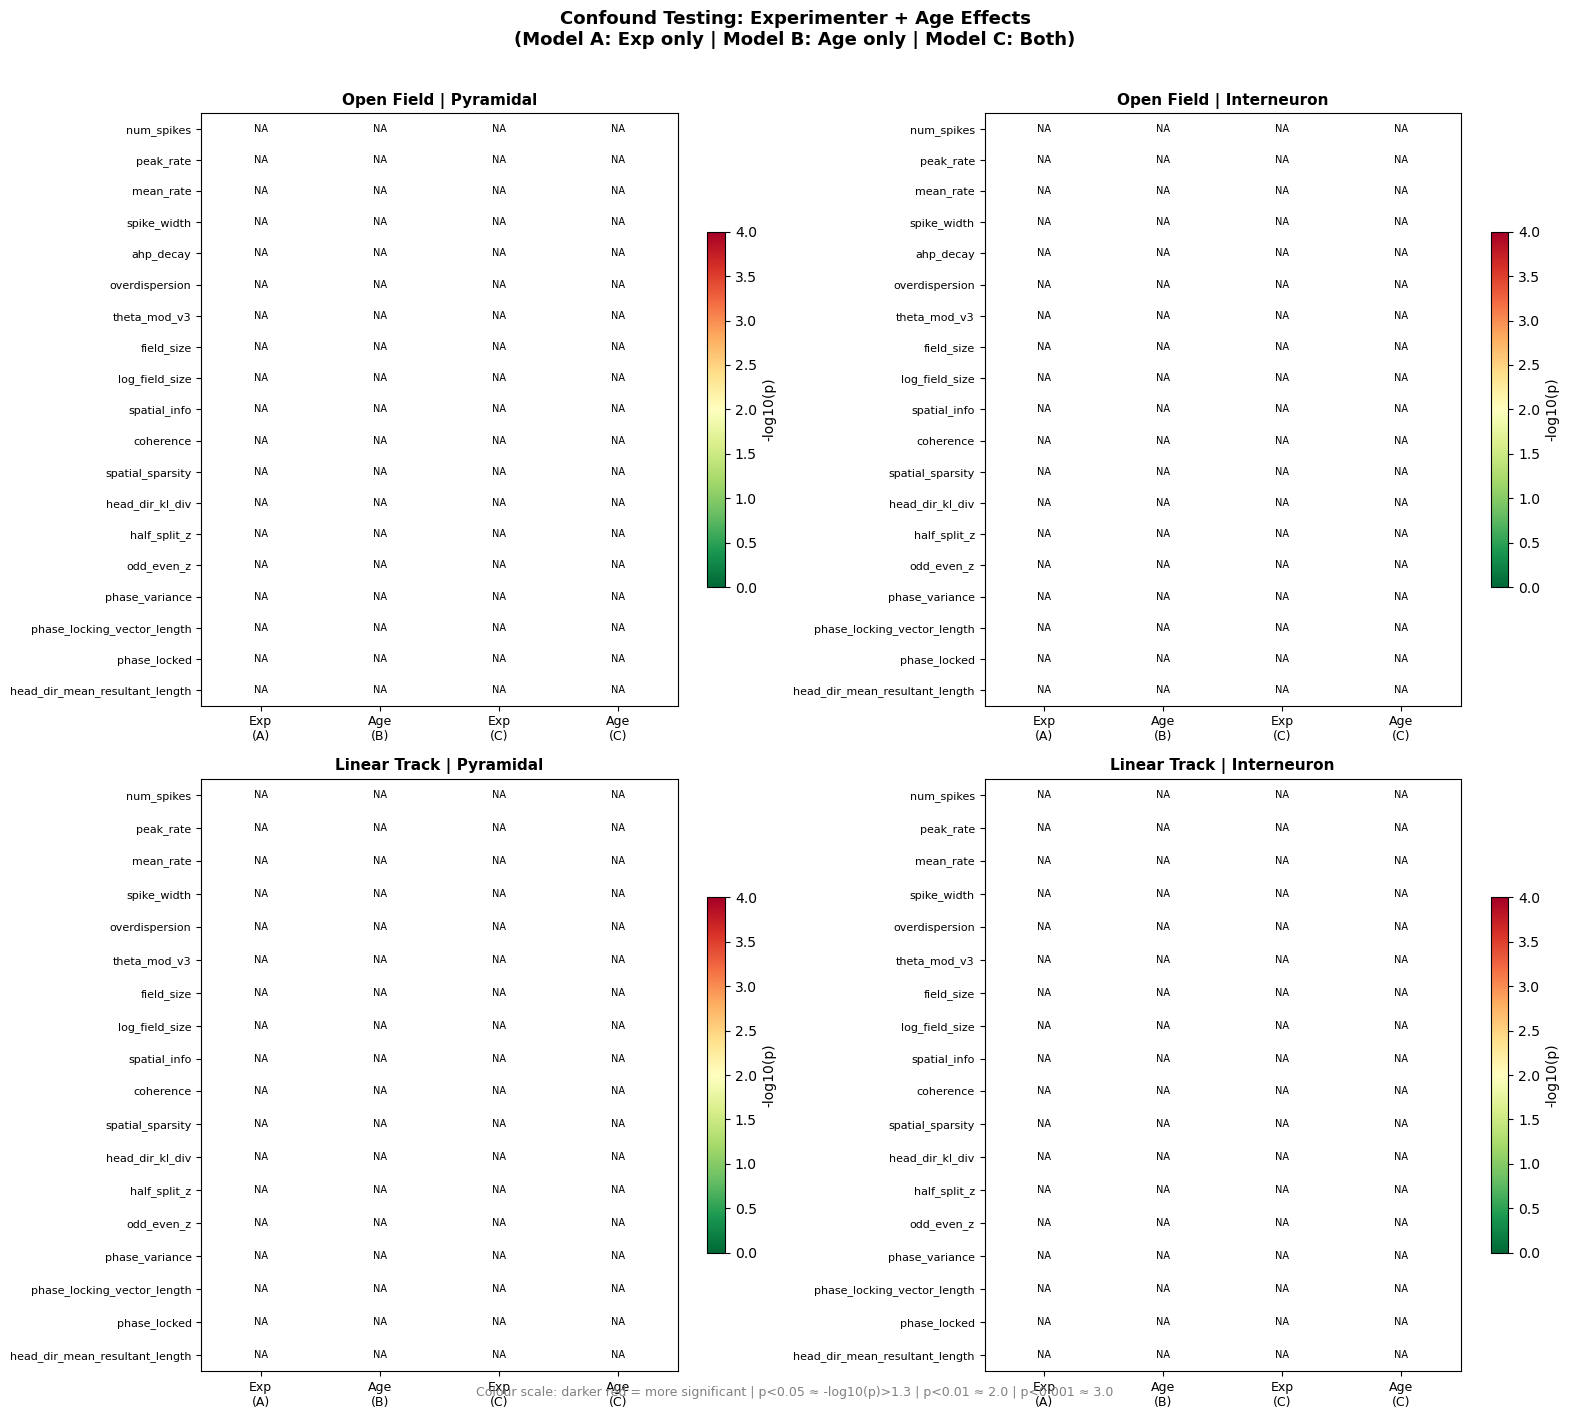

✅ Heatmap saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/confound_testing_output/10.confound_heatmap.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

cmap = plt.cm.RdYlGn_r  # red = significant, green = not significant

plot_idx = 0
for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        sub = df_results[(df_results['environment']==env) & (df_results['cell_type']==ct)].copy()
        if len(sub) == 0:
            plot_idx += 1
            continue

        ax = axes[plot_idx]

        # Build matrix: rows=metrics, cols=4 model outputs
        cols_to_plot = ['A_p_Experimenter', 'B_p_Age', 'C_p_Experimenter', 'C_p_Age']
        col_labels   = ['Exp\n(A)', 'Age\n(B)', 'Exp\n(C)', 'Age\n(C)']

        matrix = sub.set_index('metric')[cols_to_plot].astype(float)

        # -log10 transform for visualisation
        log_matrix = -np.log10(matrix.clip(lower=1e-10))

        im = ax.imshow(log_matrix.values, cmap=cmap, vmin=0, vmax=4, aspect='auto')

        # Annotate with p-values
        for i in range(log_matrix.shape[0]):
            for j in range(log_matrix.shape[1]):
                val = matrix.values[i, j]
                txt = f"{val:.3f}" if not np.isnan(val) else 'NA'
                color = 'white' if log_matrix.values[i,j] > 2 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels(col_labels, fontsize=9)
        ax.set_yticks(range(len(matrix.index)))
        ax.set_yticklabels(matrix.index, fontsize=8)
        ax.set_title(f"{env.replace('_',' ').title()} | {ct}", fontsize=11, fontweight='bold')

        # Significance threshold lines
        ax.axhline(-0.5, color='grey', linewidth=0.5)

        plt.colorbar(im, ax=ax, label='-log10(p)', shrink=0.6)
        plot_idx += 1

# Add threshold annotations
fig.text(0.5, 0.02,
         'Colour scale: darker red = more significant | p<0.05 ≈ -log10(p)>1.3 | p<0.01 ≈ 2.0 | p<0.001 ≈ 3.0',
         ha='center', fontsize=9, color='grey')

plt.suptitle('Confound Testing: Experimenter + Age Effects\n(Model A: Exp only | Model B: Age only | Model C: Both)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "10.confound_heatmap.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Heatmap saved to: {fig_path}")